# GENERACION DE MOCKDATA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Más adelante vamos a utilizar:
import pywt

SEED = 42

In [3]:
def generar_ruido_ar1(
    n: int,
    phi: float,
    sigma: float,
    rng: np.random.Generator
) -> np.ndarray:
    """
    Genera ruido autocorrelacionado mediante un proceso AR(1).

    x[t] = phi * x[t-1] + epsilon[t]

    phi cercano a 0:
        ruido poco persistente.

    phi cercano a 1:
        los movimientos tardan más en desaparecer.
    """
    ruido = np.zeros(n)
    innovaciones = rng.normal(
        loc=0.0,
        scale=sigma,
        size=n
    )

    for t in range(1, n):
        ruido[t] = phi * ruido[t - 1] + innovaciones[t]

    return ruido


def generar_shocks_transitorios(
    n: int,
    eventos: list[tuple[int, float]],
    decaimiento: float = 0.96
) -> np.ndarray:
    """
    Genera shocks que aparecen bruscamente y luego se extinguen.

    eventos:
        Lista de pares (posición, amplitud).

    decaimiento:
        Qué porcentaje del shock queda en el período siguiente.
    """
    shocks = np.zeros(n)

    for posicion, amplitud in eventos:
        if not 0 <= posicion < n:
            continue

        horizontes = np.arange(n - posicion)

        shocks[posicion:] += (
            amplitud * decaimiento ** horizontes
        )

    return shocks

In [4]:
def generar_spreads_mock(
    n: int = 1500,
    fecha_inicio: str = "2018-01-01",
    seed: int = 42
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Genera spreads simulados con componentes conocidas.

    Devuelve
    --------
    spreads_df:
        Una columna por spread simulado.

    componentes:
        Componentes verdaderas utilizadas para generar cada señal.
        Solo existen porque estamos trabajando con mock data.
    """
    rng = np.random.default_rng(seed)

    fechas = pd.bdate_range(
        start=fecha_inicio,
        periods=n
    )

    t = np.arange(n)

    componentes = {}

    # ==========================================================
    # 1. GGAL: shocks transitorios con reversión
    # ==========================================================

    lenta_ggal = (
        0.025 *
        np.sin(2 * np.pi * t / 420)
    )

    media_ggal = (
        0.012 *
        np.sin(2 * np.pi * t / 55)
    )

    shocks_ggal = generar_shocks_transitorios(
        n=n,
        eventos=[
            (350, 0.09),
            (820, -0.11),
            (1180, 0.08)
        ],
        decaimiento=0.965
    )

    ruido_ggal = generar_ruido_ar1(
        n=n,
        phi=0.75,
        sigma=0.004,
        rng=rng
    )

    componentes["GGAL_mock"] = pd.DataFrame(
        {
            "lenta": lenta_ggal,
            "media": media_ggal,
            "transitoria": shocks_ggal,
            "ruido": ruido_ggal
        },
        index=fechas
    )

    # ==========================================================
    # 2. YPF: cambio estructural permanente
    # ==========================================================

    lenta_ypf = (
        0.020 *
        np.sin(2 * np.pi * t / 500)
    )

    cambio_estructural = np.where(
        t >= 900,
        0.08,
        0.0
    )

    media_ypf = (
        0.008 *
        np.sin(2 * np.pi * t / 80)
    )

    shocks_ypf = generar_shocks_transitorios(
        n=n,
        eventos=[
            (280, -0.06),
            (1250, 0.05)
        ],
        decaimiento=0.97
    )

    ruido_ypf = generar_ruido_ar1(
        n=n,
        phi=0.82,
        sigma=0.0035,
        rng=rng
    )

    componentes["YPF_mock"] = pd.DataFrame(
        {
            "lenta": lenta_ypf + cambio_estructural,
            "media": media_ypf,
            "transitoria": shocks_ypf,
            "ruido": ruido_ypf
        },
        index=fechas
    )

    # ==========================================================
    # 3. BMA: oscilaciones rápidas y ruido persistente
    # ==========================================================

    lenta_bma = (
        0.018 *
        np.sin(2 * np.pi * t / 360)
    )

    media_bma = (
        0.015 *
        np.sin(2 * np.pi * t / 35)
    )

    shocks_bma = generar_shocks_transitorios(
        n=n,
        eventos=[
            (600, 0.07),
            (1040, -0.075)
        ],
        decaimiento=0.955
    )

    ruido_bma = generar_ruido_ar1(
        n=n,
        phi=0.90,
        sigma=0.003,
        rng=rng
    )

    componentes["BMA_mock"] = pd.DataFrame(
        {
            "lenta": lenta_bma,
            "media": media_bma,
            "transitoria": shocks_bma,
            "ruido": ruido_bma
        },
        index=fechas
    )

    # La señal observada es la suma de sus componentes.
    spreads_df = pd.DataFrame(
        {
            nombre: componentes_ticker.sum(axis=1)
            for nombre, componentes_ticker
            in componentes.items()
        },
        index=fechas
    )

    return spreads_df, componentes

# Genero el dataset

In [5]:
spreads_df, componentes_mock = generar_spreads_mock(
    n=1500,
    fecha_inicio="2018-01-01",
    seed=SEED
)

display(spreads_df.head())
display(spreads_df.describe())
spreads_df.shape

,GGAL_mock,YPF_mock,BMA_mock
2018-01-01,0.000000,0.000000,0.000000
2018-01-02,-0.002418,-0.001307,0.005056
2018-01-03,0.003348,0.004599,0.013654
2018-01-04,0.008828,0.006111,0.010972
2018-01-05,0.001741,0.005597,0.012431


,GGAL_mock,YPF_mock,BMA_mock
count,1500.000000,1500.000000,1500.000000
mean,0.003023,0.031239,0.000420
std,0.023181,0.045406,0.020625
min,-0.129239,-0.072146,-0.100772
25%,-0.012973,-0.003021,-0.013099
50%,0.005876,0.017026,-0.000078
75%,0.019074,0.075315,0.013741
max,0.079168,0.129520,0.079819


(1500, 3)

## Validacion de contrato

In [6]:
def validar_spreads(spreads: pd.DataFrame) -> None:
    """
    Valida que el input tenga el formato esperado
    por el módulo de procesamiento de señales.
    """
    if not isinstance(spreads, pd.DataFrame):
        raise TypeError(
            "El input debe ser un pandas DataFrame."
        )

    if not isinstance(spreads.index, pd.DatetimeIndex):
        raise TypeError(
            "El índice debe ser un DatetimeIndex."
        )

    if not spreads.index.is_monotonic_increasing:
        raise ValueError(
            "Las fechas deben estar ordenadas."
        )

    if not spreads.index.is_unique:
        raise ValueError(
            "Hay fechas duplicadas."
        )

    columnas_no_numericas = (
        spreads.select_dtypes(exclude="number").columns
    )

    if len(columnas_no_numericas) > 0:
        raise TypeError(
            "Todas las columnas deben ser numéricas. "
            f"Columnas problemáticas: "
            f"{list(columnas_no_numericas)}"
        )

    if spreads.isna().all().any():
        columnas_vacias = spreads.columns[
            spreads.isna().all()
        ].tolist()

        raise ValueError(
            "Hay columnas completamente vacías: "
            f"{columnas_vacias}"
        )

    print("El DataFrame cumple el contrato.")
    print(f"Observaciones: {len(spreads):,}")
    print(f"Señales: {spreads.shape[1]}")
    print(
        f"Período: {spreads.index.min().date()} "
        f"a {spreads.index.max().date()}"
    )


validar_spreads(spreads_df)

El DataFrame cumple el contrato.
Observaciones: 1,500
Señales: 3
Período: 2018-01-01 a 2023-09-29


## Visualizamos el Mock

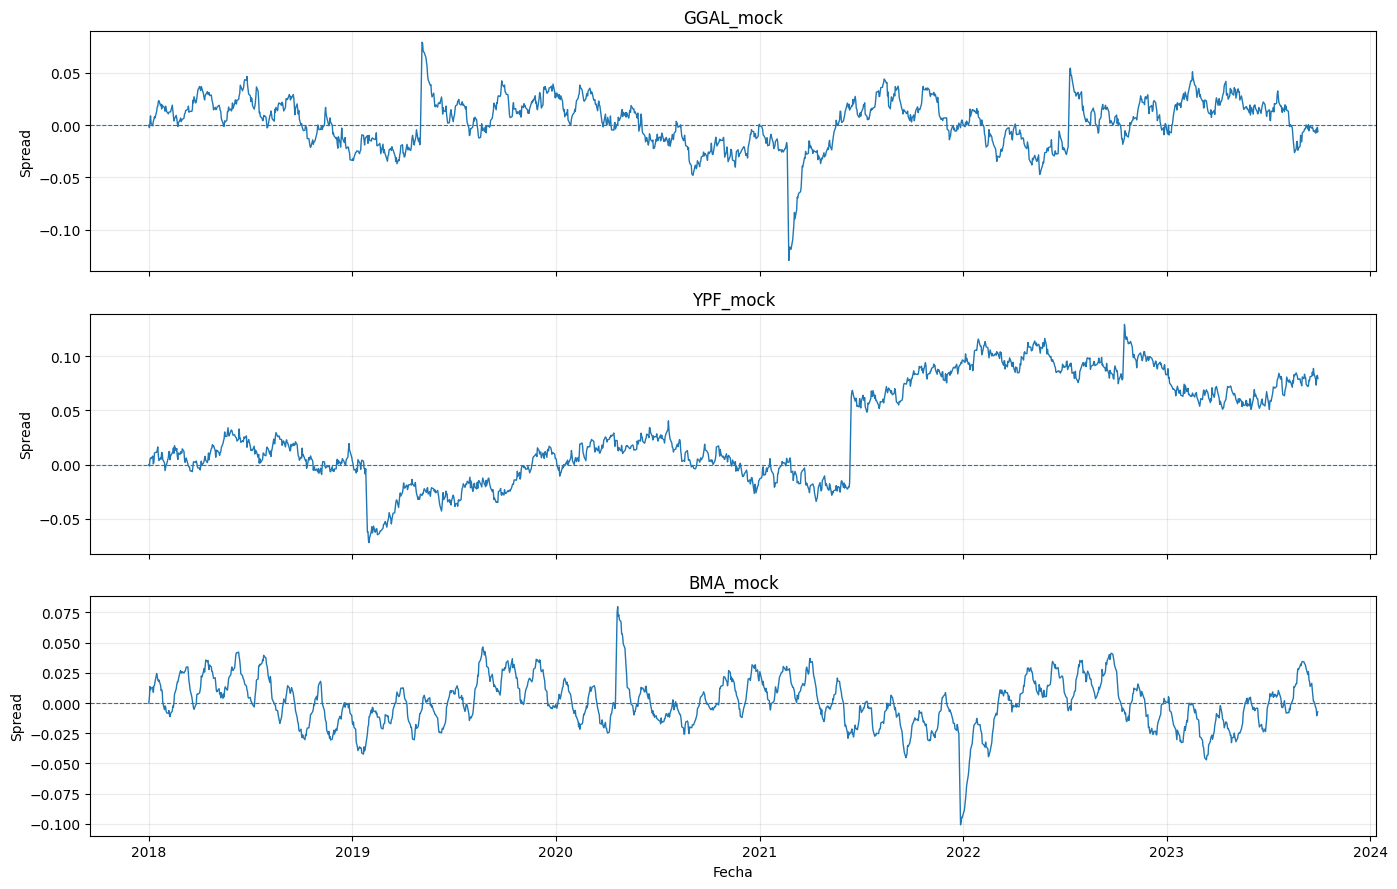

In [7]:
fig, axes = plt.subplots(
    nrows=len(spreads_df.columns),
    ncols=1,
    figsize=(14, 9),
    sharex=True
)

for ax, columna in zip(axes, spreads_df.columns):
    ax.plot(
        spreads_df.index,
        spreads_df[columna],
        linewidth=1
    )

    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(columna)
    ax.set_ylabel("Spread")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

## visualizar las componentes verdaderas
#### Como los datos son simulados, conocemos la composición real de cada señal.

#### Esto es muy útil: más adelante podremos comprobar si la aproximación de Mallat recupera efectivamente la componente lenta.

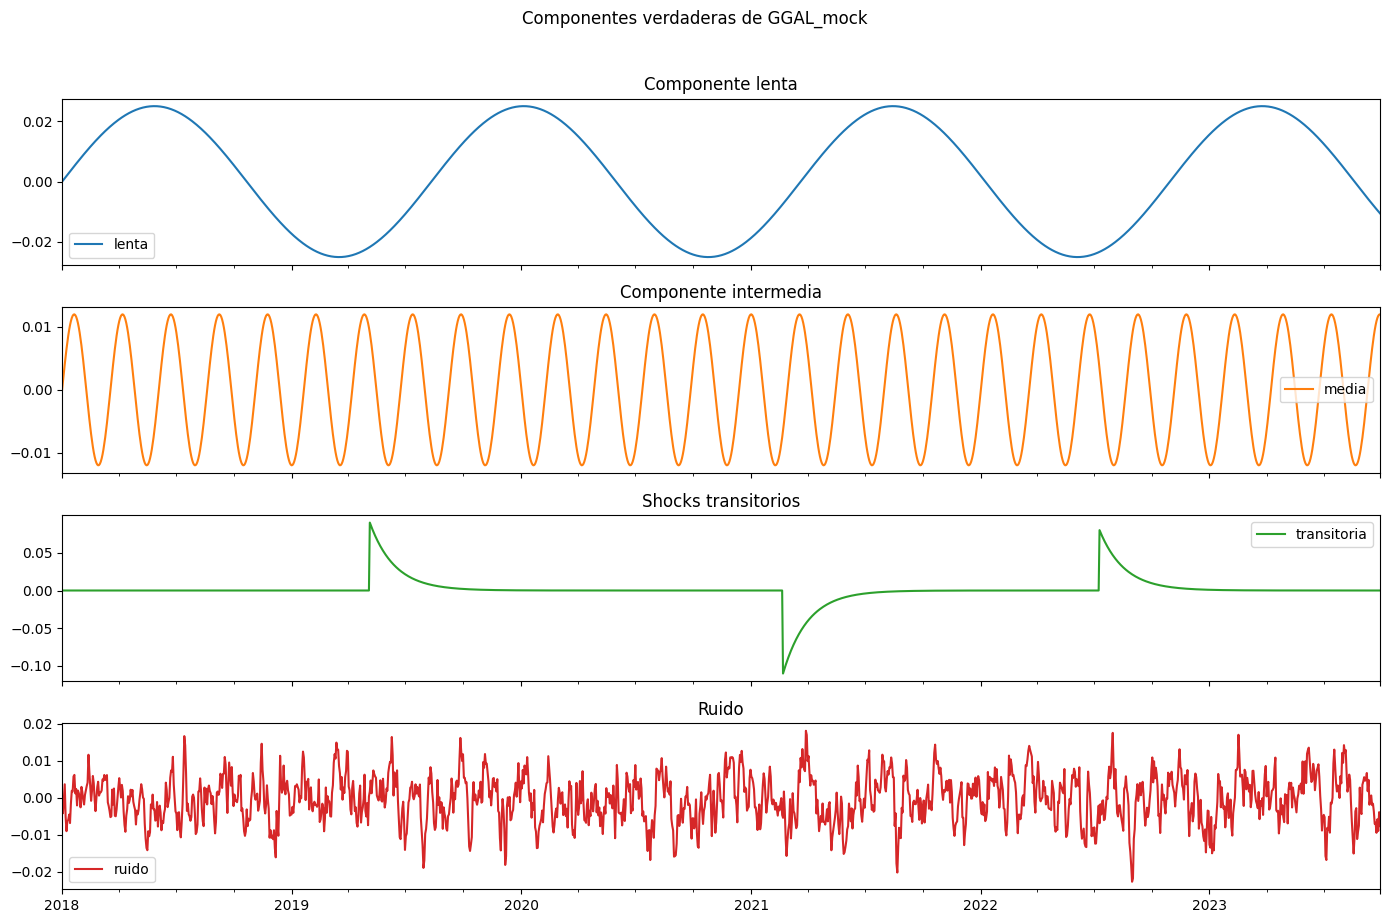

In [8]:
ticker_ejemplo = "GGAL_mock"

componentes_mock[ticker_ejemplo].plot(
    subplots=True,
    figsize=(14, 9),
    sharex=True,
    title=[
        "Componente lenta",
        "Componente intermedia",
        "Shocks transitorios",
        "Ruido"
    ]
)

plt.suptitle(
    f"Componentes verdaderas de {ticker_ejemplo}",
    y=1.02
)

plt.tight_layout()
plt.show()

# Hacemos una FFT descriptivas y vemos que informacion nos da, que informacion pierde y como comparamos con Mallat

## Queremos contestar: ¿Que escalas temporales aparecen en cada spread simulado?
### Frecuencia alta -> movimiento rapidos, Frecuencia baja -> movimiento lentos.
### Tambien vamos a ver su limitacion; la FFT indica que frecuencias existen globalmente, pero no en que momento aparecen.

## La siguente funcion nos da : Frecuencia (cuantas oscilaciones ocurren por rueda), Periodo, Amplitud (cuanto aporta una frecuencia a la señar) y Potencia (cantidad de variacion de la señal asociada a esa frecuencia)

In [9]:
def calcular_espectro_fft(
    serie: pd.Series,
    paso_temporal: float = 1.0
) -> pd.DataFrame:
    """
    Calcula el espectro de Fourier unilateral de una serie temporal.

    Parámetros
    ----------
    serie:
        Señal temporal. En nuestro proyecto será un spread.

    paso_temporal:
        Distancia entre observaciones.
        Como tenemos una observación por rueda, usamos 1.

    Devuelve
    --------
    DataFrame con:
        - frecuencia
        - período equivalente
        - amplitud
        - potencia
        - proporción de potencia
    """
    serie_limpia = serie.dropna().astype(float)

    if len(serie_limpia) < 4:
        raise ValueError(
            "La serie necesita al menos cuatro observaciones."
        )

    # Quitamos la media porque no queremos que la componente
    # constante domine el espectro.
    señal_centrada = (
        serie_limpia - serie_limpia.mean()
    ).to_numpy()

    n = len(señal_centrada)

    # FFT para señales reales.
    coeficientes = np.fft.rfft(señal_centrada)

    # Frecuencias positivas, incluida frecuencia cero.
    frecuencias = np.fft.rfftfreq(
        n=n,
        d=paso_temporal
    )

    # Amplitud unilateral.
    amplitudes = np.abs(coeficientes) / n

    # Se duplican las componentes positivas porque rfft
    # solamente conserva la mitad del espectro.
    if n % 2 == 0:
        amplitudes[1:-1] *= 2
    else:
        amplitudes[1:] *= 2

    # Potencia asociada a cada frecuencia.
    potencia = np.abs(coeficientes) ** 2 / n

    potencia_total = potencia.sum()

    if potencia_total > 0:
        proporcion_potencia = potencia / potencia_total
    else:
        proporcion_potencia = np.zeros_like(potencia)

    # Período = 1 / frecuencia.
    # La frecuencia cero tiene período infinito.
    periodos = np.full_like(
        frecuencias,
        fill_value=np.inf,
        dtype=float
    )

    mascara_no_cero = frecuencias > 0

    periodos[mascara_no_cero] = (
        1 / frecuencias[mascara_no_cero]
    )

    espectro = pd.DataFrame(
        {
            "frecuencia": frecuencias,
            "periodo_ruedas": periodos,
            "amplitud": amplitudes,
            "potencia": potencia,
            "proporcion_potencia": proporcion_potencia
        }
    )

    return espectro

## Calculamos los espectros de todos los spreads

In [10]:
resultados_fft = {
    columna: calcular_espectro_fft(spreads_df[columna])
    for columna in spreads_df.columns
}

resultados_fft["GGAL_mock"].head()


,frecuencia,periodo_ruedas,amplitud,potencia,proporcion_potencia
0,0.000000,inf,5.458597e-19,4.469441e-34,1.109700e-33
1,0.000667,1500.0,1.004278e-02,3.782157e-02,9.390566e-02
2,0.001333,750.0,5.921244e-03,1.314793e-02,3.264445e-02
3,0.002000,500.0,1.385128e-02,7.194677e-02,1.786337e-01
4,0.002667,375.0,1.245998e-02,5.821920e-02,1.445501e-01


### Graficamos señal y espectro

In [11]:
def graficar_fft(
    serie: pd.Series,
    espectro: pd.DataFrame,
    titulo: str,
    periodo_minimo: float = 2,
    periodo_maximo: float = 700
) -> None:
    """
    Grafica una señal temporal y su espectro
    expresado en períodos.
    """
    espectro_grafico = espectro[
        (espectro["frecuencia"] > 0)
        & (
            espectro["periodo_ruedas"]
            >= periodo_minimo
        )
        & (
            espectro["periodo_ruedas"]
            <= periodo_maximo
        )
    ].copy()

    espectro_grafico = espectro_grafico.sort_values(
        "periodo_ruedas"
    )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(14, 8)
    )

    # Señal temporal.
    axes[0].plot(
        serie.index,
        serie.values,
        linewidth=1
    )

    axes[0].axhline(
        y=serie.mean(),
        linestyle="--",
        linewidth=0.8
    )

    axes[0].set_title(
        f"Señal temporal — {titulo}"
    )
    axes[0].set_ylabel("Spread")
    axes[0].grid(alpha=0.25)

    # Espectro.
    axes[1].plot(
        espectro_grafico["periodo_ruedas"],
        espectro_grafico["amplitud"],
        linewidth=1
    )

    axes[1].set_xscale("log")

    axes[1].set_title(
        "Espectro global de Fourier"
    )
    axes[1].set_xlabel(
        "Período aproximado, en ruedas"
    )
    axes[1].set_ylabel("Amplitud")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

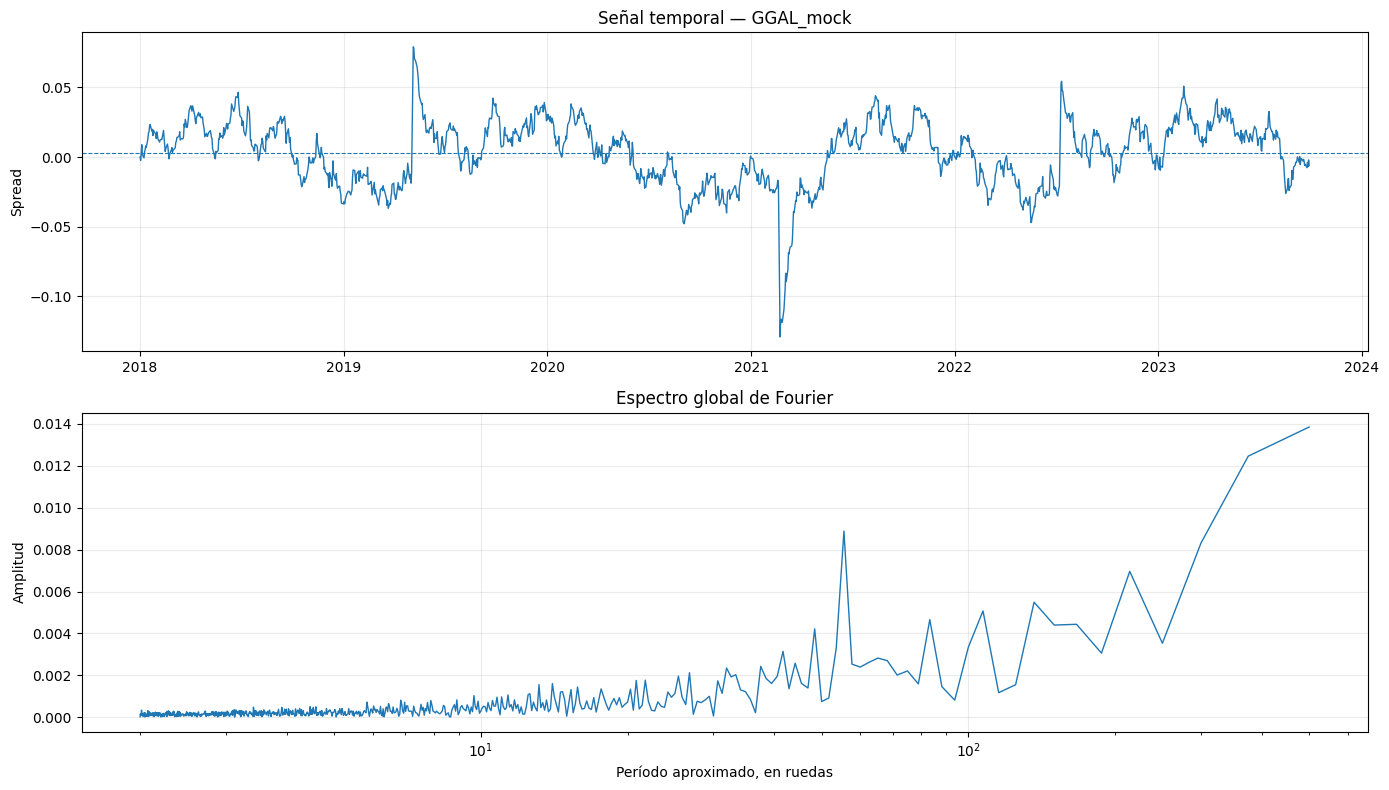

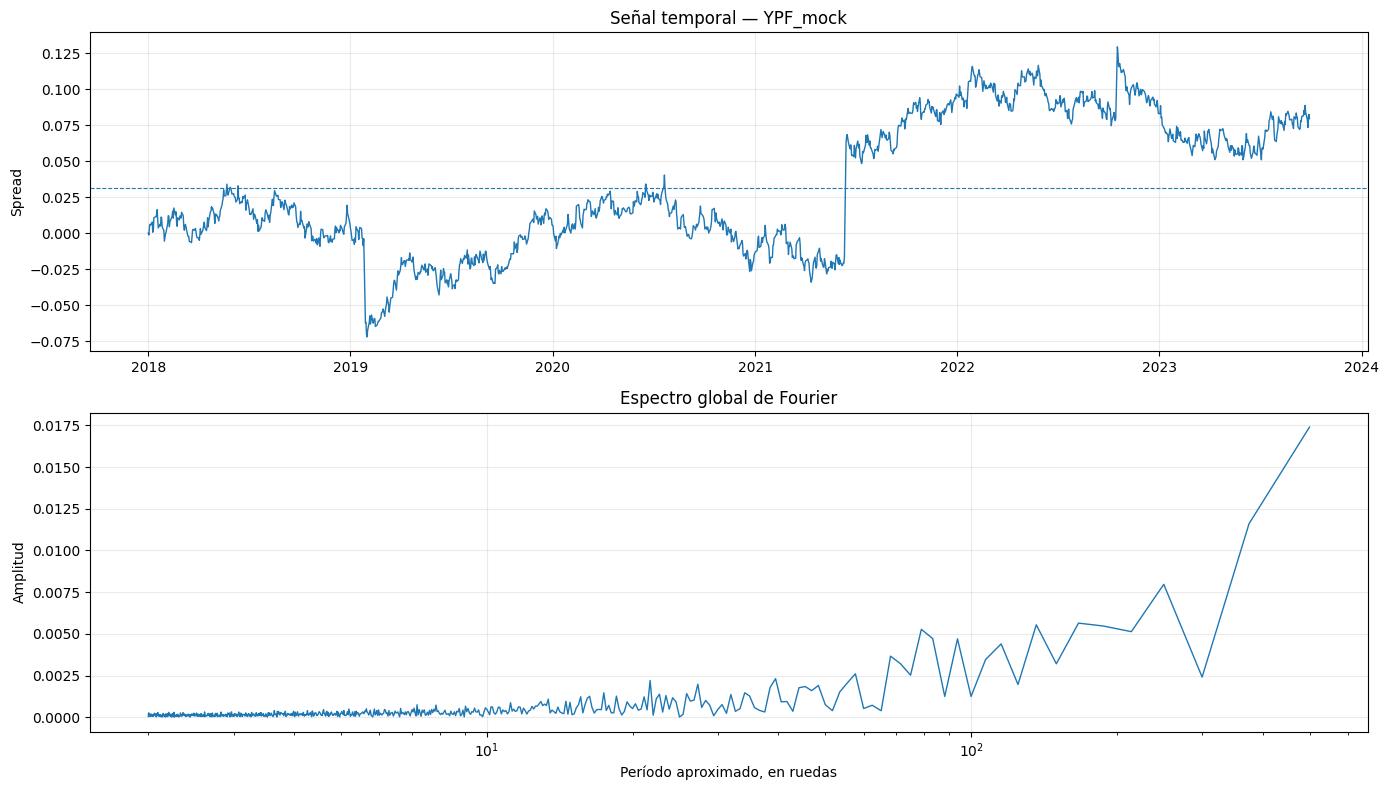

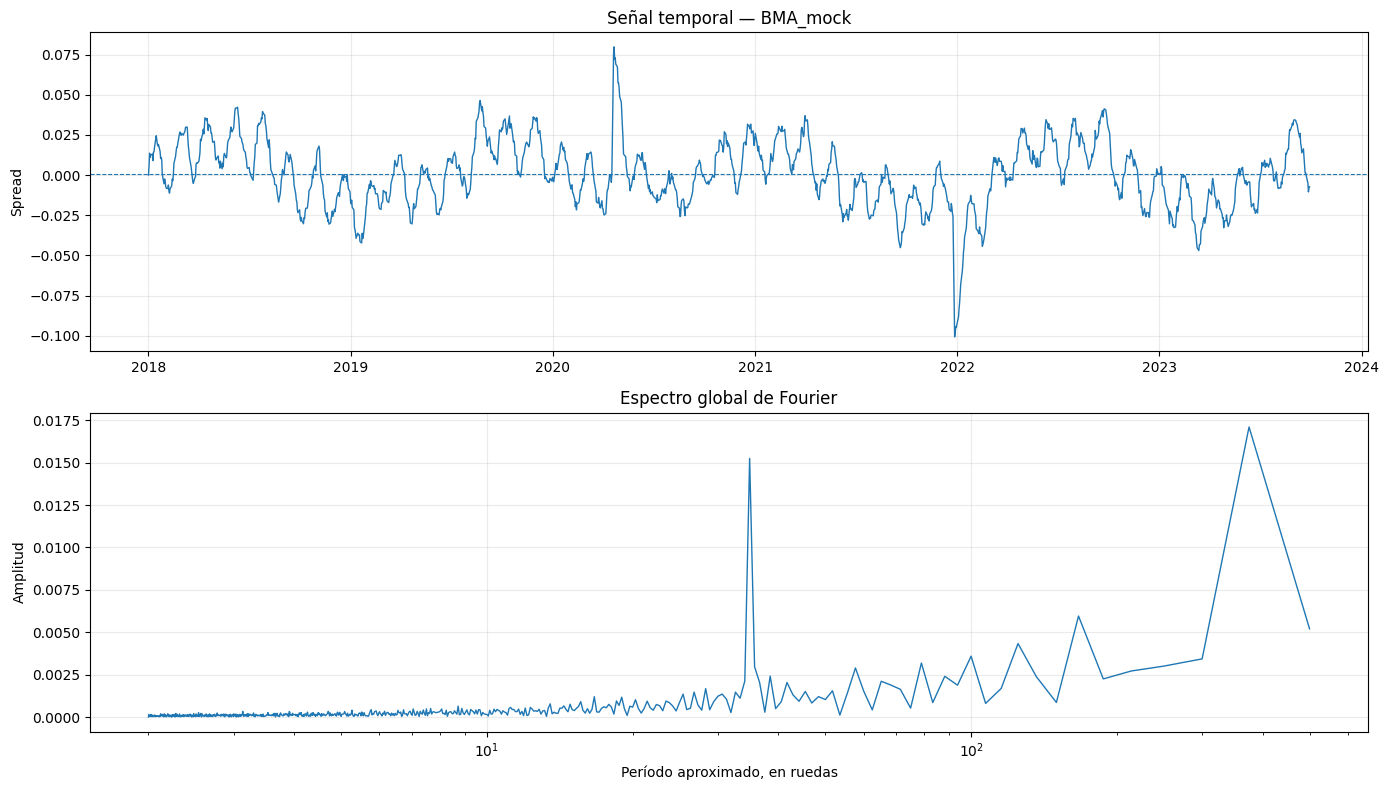

In [12]:
for columna in spreads_df.columns:
    graficar_fft(
        serie=spreads_df[columna],
        espectro=resultados_fft[columna],
        titulo=columna
    )

### Sacamos los picos principales

In [13]:
def obtener_picos_fft(
    espectro: pd.DataFrame,
    cantidad: int = 5,
    periodo_minimo: float = 5,
    periodo_maximo: float = 700
) -> pd.DataFrame:
    """
    Obtiene los principales máximos locales del espectro.
    """
    datos = espectro[
        (espectro["frecuencia"] > 0)
        & (
            espectro["periodo_ruedas"]
            >= periodo_minimo
        )
        & (
            espectro["periodo_ruedas"]
            <= periodo_maximo
        )
    ].copy()

    datos = datos.sort_values(
        "frecuencia"
    ).reset_index(drop=True)

    amplitudes = datos["amplitud"].to_numpy()

    if len(amplitudes) < 3:
        return pd.DataFrame()

    es_maximo_local = np.zeros(
        len(datos),
        dtype=bool
    )

    es_maximo_local[1:-1] = (
        (amplitudes[1:-1] > amplitudes[:-2])
        & (amplitudes[1:-1] >= amplitudes[2:])
    )

    picos = datos[es_maximo_local].copy()

    picos = picos.nlargest(
        cantidad,
        columns="amplitud"
    )

    return picos[
        [
            "frecuencia",
            "periodo_ruedas",
            "amplitud",
            "proporcion_potencia"
        ]
    ].reset_index(drop=True)

In [14]:
picos_por_señal = {}

for columna, espectro in resultados_fft.items():
    picos = obtener_picos_fft(
        espectro,
        cantidad=6
    )

    picos_por_señal[columna] = picos

    print(f"\nPrincipales picos de {columna}")
    display(picos)


Principales picos de GGAL_mock


,frecuencia,periodo_ruedas,amplitud,proporcion_potencia
0,0.018000,55.555556,0.008885,0.073508
1,0.004667,214.285714,0.006962,0.045127
2,0.007333,136.363636,0.005492,0.028082
3,0.009333,107.142857,0.005074,0.023975
4,0.012000,83.333333,0.004661,0.020230
5,0.006000,166.666667,0.004436,0.018325



Principales picos de YPF_mock


,frecuencia,periodo_ruedas,amplitud,proporcion_potencia
0,0.004000,250.000000,0.007967,0.015406
1,0.006000,166.666667,0.005643,0.007727
2,0.007333,136.363636,0.005539,0.007445
3,0.012667,78.947368,0.005271,0.006742
4,0.010667,93.750000,0.004696,0.005351
5,0.008667,115.384615,0.004398,0.004695



Principales picos de BMA_mock


,frecuencia,periodo_ruedas,amplitud,proporcion_potencia
0,0.002667,375.000000,0.017097,0.343815
1,0.028667,34.883721,0.015246,0.273407
2,0.006000,166.666667,0.005958,0.041757
3,0.008000,125.000000,0.004338,0.022138
4,0.010000,100.000000,0.003594,0.015192
5,0.012667,78.947368,0.003192,0.011983


## SACAR: validacion con datos simulados (REVISAR RESULTADOS)

In [15]:
periodos_verdaderos = {
    "GGAL_mock": [55, 420],
    "YPF_mock": [80, 500],
    "BMA_mock": [35, 360]
}

for ticker, periodos in periodos_verdaderos.items():
    print(
        f"{ticker}: períodos simulados = {periodos}"
    )

    display(
        picos_por_señal[ticker][
            ["periodo_ruedas", "amplitud"]
        ]
    )

GGAL_mock: períodos simulados = [55, 420]


,periodo_ruedas,amplitud
0,55.555556,0.008885
1,214.285714,0.006962
2,136.363636,0.005492
3,107.142857,0.005074
4,83.333333,0.004661
5,166.666667,0.004436


YPF_mock: períodos simulados = [80, 500]


,periodo_ruedas,amplitud
0,250.000000,0.007967
1,166.666667,0.005643
2,136.363636,0.005539
3,78.947368,0.005271
4,93.750000,0.004696
5,115.384615,0.004398


BMA_mock: períodos simulados = [35, 360]


,periodo_ruedas,amplitud
0,375.000000,0.017097
1,34.883721,0.015246
2,166.666667,0.005958
3,125.000000,0.004338
4,100.000000,0.003594
5,78.947368,0.003192


### Dos señales con la misma frecuencia en momentos distintos (demo de que Fourier no localiza CUANDO ocurre algo)

In [16]:
n_demo = 800
t_demo = np.arange(n_demo)

periodo_demo = 40

oscilacion = np.sin(
    2 * np.pi * t_demo / periodo_demo
)

senal_inicio = np.zeros(n_demo)

senal_inicio[100:300] = oscilacion[100:300]

# Desplazamos exactamente la misma señal.
senal_final = np.roll(
    senal_inicio,
    shift=400
)

fechas_demo = pd.bdate_range(
    start="2020-01-01",
    periods=n_demo
)

serie_inicio = pd.Series(
    senal_inicio,
    index=fechas_demo,
    name="Oscilación al comienzo"
)

serie_final = pd.Series(
    senal_final,
    index=fechas_demo,
    name="Oscilación al final"
)

espectro_inicio = calcular_espectro_fft(
    serie_inicio
)

espectro_final = calcular_espectro_fft(
    serie_final
)

### Comparar las señales y los espectros

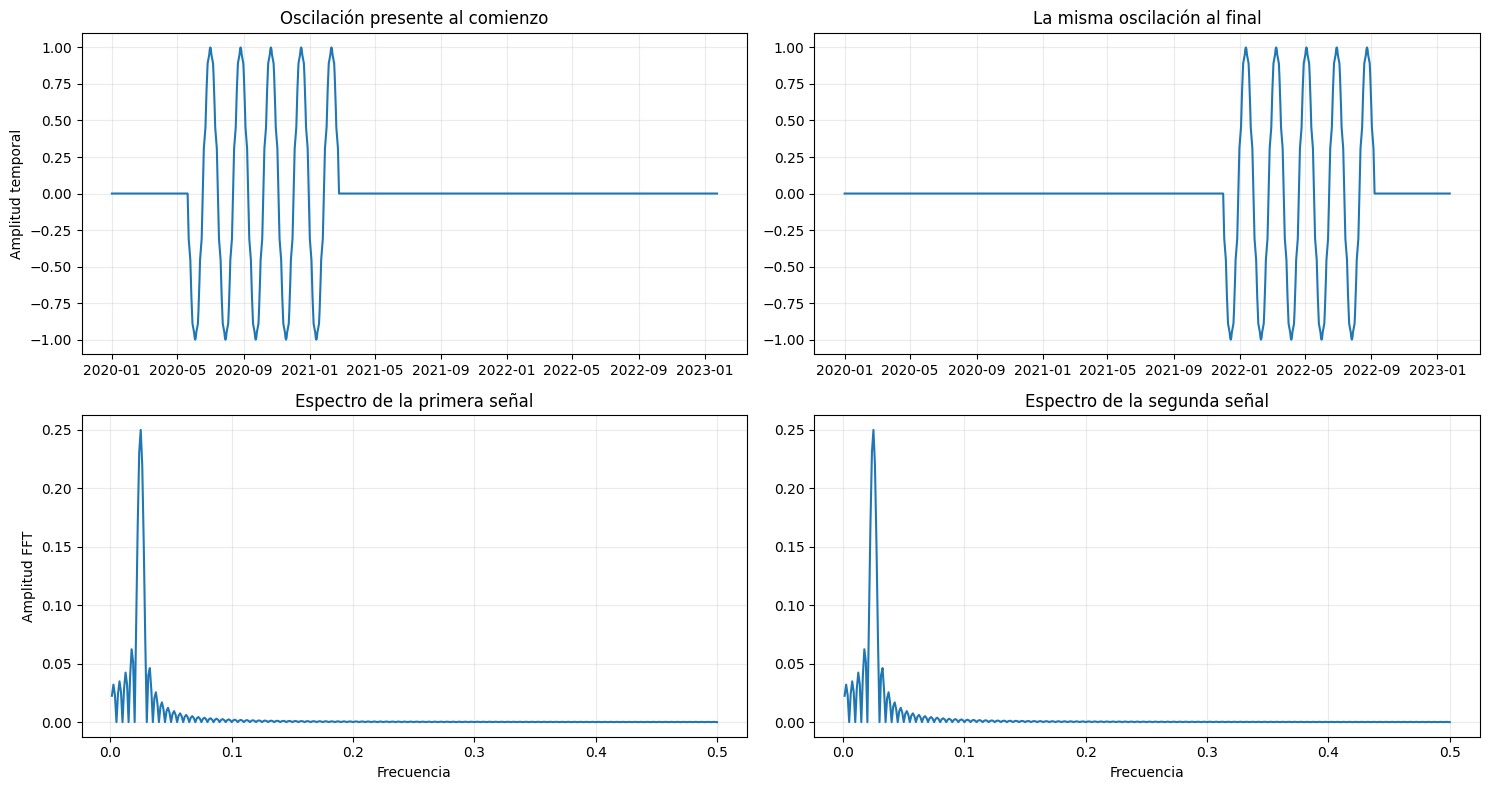

In [17]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 8)
)

# Señales temporales.
axes[0, 0].plot(
    serie_inicio.index,
    serie_inicio.values
)

axes[0, 0].set_title(
    "Oscilación presente al comienzo"
)

axes[0, 1].plot(
    serie_final.index,
    serie_final.values
)

axes[0, 1].set_title(
    "La misma oscilación al final"
)

# Quitamos frecuencia cero para graficar.
fft_inicio_plot = espectro_inicio[
    espectro_inicio["frecuencia"] > 0
]

fft_final_plot = espectro_final[
    espectro_final["frecuencia"] > 0
]

axes[1, 0].plot(
    fft_inicio_plot["frecuencia"],
    fft_inicio_plot["amplitud"]
)

axes[1, 0].set_title(
    "Espectro de la primera señal"
)

axes[1, 1].plot(
    fft_final_plot["frecuencia"],
    fft_final_plot["amplitud"]
)

axes[1, 1].set_title(
    "Espectro de la segunda señal"
)

for ax in axes.flat:
    ax.grid(alpha=0.25)

axes[0, 0].set_ylabel("Amplitud temporal")
axes[1, 0].set_ylabel("Amplitud FFT")

axes[1, 0].set_xlabel("Frecuencia")
axes[1, 1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

#### VER GRAFICO DE ARRIBA VS MALLAT

##### Esto ocurre porque desplazar una señal en el tiempo cambia la fase de sus coeficientes de Fourier, pero no su magnitud.

In [18]:
diferencia_maxima = np.max(
    np.abs(
        espectro_inicio["amplitud"].to_numpy()
        - espectro_final["amplitud"].to_numpy()
    )
)

print(
    "Máxima diferencia entre los espectros:",
    diferencia_maxima
)

Máxima diferencia entre los espectros: 2.7755575615628914e-17


# Mallat

### Configuracion

In [19]:
WAVELET = "db4"
MODO_BORDE = "symmetric"
NIVEL_MALLAT = 6

### Tabla de escalas

In [20]:
def construir_tabla_escalas(
    nivel_maximo: int
) -> pd.DataFrame:
    """
    Construye una interpretación aproximada
    de las escalas temporales de cada detalle.
    """
    filas = []

    for nivel in range(1, nivel_maximo + 1):
        periodo_minimo = 2 ** nivel
        periodo_maximo = 2 ** (nivel + 1)

        filas.append(
            {
                "componente": f"D{nivel}",
                "periodo_minimo_ruedas": periodo_minimo,
                "periodo_maximo_ruedas": periodo_maximo,
                "interpretacion": (
                    f"Movimientos de aproximadamente "
                    f"{periodo_minimo} a "
                    f"{periodo_maximo} ruedas"
                )
            }
        )

    filas.append(
        {
            "componente": f"A{nivel_maximo}",
            "periodo_minimo_ruedas": 2 ** (nivel_maximo + 1),
            "periodo_maximo_ruedas": np.inf,
            "interpretacion": (
                "Movimientos más lentos que "
                f"{2 ** (nivel_maximo + 1)} ruedas"
            )
        }
    )

    return pd.DataFrame(filas)


tabla_escalas = construir_tabla_escalas(
    NIVEL_MALLAT
)

display(tabla_escalas)

,componente,periodo_minimo_ruedas,periodo_maximo_ruedas,interpretacion
0,D1,2,4.0,Movimientos de aproximadamente 2 a 4 ruedas
1,D2,4,8.0,Movimientos de aproximadamente 4 a 8 ruedas
2,D3,8,16.0,Movimientos de aproximadamente 8 a 16 ruedas
3,D4,16,32.0,Movimientos de aproximadamente 16 a 32 ruedas
4,D5,32,64.0,Movimientos de aproximadamente 32 a 64 ruedas
5,D6,64,128.0,Movimientos de aproximadamente 64 a 128 ruedas
6,A6,128,inf,Movimientos más lentos que 128 ruedas


### Verificar nivel maximo disponible

In [21]:
def obtener_niveles_maximos(
    spreads: pd.DataFrame,
    wavelet: str
) -> pd.Series:
    """
    Calcula el máximo nivel recomendado
    para cada señal.
    """
    wavelet_obj = pywt.Wavelet(wavelet)

    niveles = {}

    for columna in spreads.columns:
        serie = spreads[columna].dropna()

        niveles[columna] = pywt.dwt_max_level(
            data_len=len(serie),
            filter_len=wavelet_obj.dec_len
        )

    return pd.Series(
        niveles,
        name="nivel_maximo_recomendado"
    )


niveles_maximos = obtener_niveles_maximos(
    spreads=spreads_df,
    wavelet=WAVELET
)

display(niveles_maximos)

GGAL_mock    7
YPF_mock     7
BMA_mock     7
Name: nivel_maximo_recomendado, dtype: int64

In [22]:
if NIVEL_MALLAT > niveles_maximos.min():
    raise ValueError(
        f"El nivel {NIVEL_MALLAT} es demasiado alto. "
        f"El menor nivel máximo disponible es "
        f"{niveles_maximos.min()}."
    )

### Descomponemos los spreads

In [23]:
def descomponer_mallat(
    spreads: pd.DataFrame,
    wavelet: str = "db4",
    nivel: int = 6,
    modo: str = "symmetric"
) -> dict:
    """
    Aplica la descomposición wavelet discreta
    a cada columna del DataFrame.
    """
    wavelet_obj = pywt.Wavelet(wavelet)

    resultados = {}

    for columna in spreads.columns:
        serie = spreads[columna].astype(float).copy()

        if serie.isna().any():
            raise ValueError(
                f"La serie {columna} contiene valores faltantes. "
                "No deben eliminarse silenciosamente porque eso "
                "modificaría el espaciado temporal."
            )

        nivel_maximo = pywt.dwt_max_level(
            data_len=len(serie),
            filter_len=wavelet_obj.dec_len
        )

        if nivel > nivel_maximo:
            raise ValueError(
                f"El nivel {nivel} no es válido para {columna}. "
                f"Máximo recomendado: {nivel_maximo}."
            )

        # Creamos una copia escribible y contigua.
        datos = np.ascontiguousarray(
            serie.to_numpy(
                dtype=np.float64,
                copy=True
            )
        )

        coeficientes = pywt.wavedec(
            data=datos,
            wavelet=wavelet_obj,
            mode=modo,
            level=nivel
        )

        resultados[columna] = {
            "serie_original": serie,
            "coeficientes": coeficientes,
            "wavelet": wavelet,
            "modo": modo,
            "nivel": nivel,
            "nivel_maximo": nivel_maximo
        }

    return resultados

In [24]:
resultados_mallat = descomponer_mallat(
    spreads=spreads_df,
    wavelet=WAVELET,
    nivel=NIVEL_MALLAT,
    modo=MODO_BORDE
)

#### Inspeccionamos los resultados

In [25]:
coeficientes_ggal = (
    resultados_mallat["GGAL_mock"]["coeficientes"]
)

for indice, coeficiente in enumerate(
    coeficientes_ggal
):
    print(
        f"Posición {indice}: "
        f"{len(coeficiente)} coeficientes"
    )

Posición 0: 30 coeficientes
Posición 1: 30 coeficientes
Posición 2: 53 coeficientes
Posición 3: 100 coeficientes
Posición 4: 193 coeficientes
Posición 5: 380 coeficientes
Posición 6: 753 coeficientes


## Recontruimos los componentes
### La descomposición produce coeficientes, pero queremos volver a obtener señales con el mismo largo temporal que el spread original.

#### Recontruccion de un componente

In [26]:
def reconstruir_componente(
    coeficientes: list[np.ndarray],
    wavelet: str,
    modo: str,
    largo_original: int,
    componente: str | int
) -> np.ndarray:
    """
    Reconstruye una aproximación o un detalle.

    componente:
        "A" para la aproximación final.
        Un entero j para reconstruir D_j.
    """
    nivel = len(coeficientes) - 1

    coeficientes_seleccionados = [
        np.zeros_like(coeficiente)
        for coeficiente in coeficientes
    ]

    if componente == "A":
        coeficientes_seleccionados[0] = (
            coeficientes[0].copy()
        )

    elif isinstance(componente, int):
        if componente < 1 or componente > nivel:
            raise ValueError(
                f"El detalle debe estar entre "
                f"D1 y D{nivel}."
            )

        # En wavedec:
        # posición 1 = D_nivel
        # posición nivel = D1
        indice_coeficiente = (
            nivel - componente + 1
        )

        coeficientes_seleccionados[
            indice_coeficiente
        ] = coeficientes[indice_coeficiente].copy()

    else:
        raise ValueError(
            "componente debe ser 'A' "
            "o un número entero."
        )

    reconstruccion = pywt.waverec(
        coeficientes_seleccionados,
        wavelet=wavelet,
        mode=modo
    )

    # waverec puede devolver una observación adicional.
    return reconstruccion[:largo_original]

### Recontruccion de todas las componentes

In [27]:
def reconstruir_todas_las_componentes(
    resultado: dict
) -> pd.DataFrame:
    """
    Reconstruye A_L y todos los detalles D_j
    en el dominio temporal original.
    """
    serie = resultado["serie_original"]
    coeficientes = resultado["coeficientes"]
    wavelet = resultado["wavelet"]
    modo = resultado["modo"]
    nivel = resultado["nivel"]

    largo = len(serie)

    reconstrucciones = pd.DataFrame(
        index=serie.index
    )

    reconstrucciones["original"] = serie

    reconstrucciones[f"A{nivel}"] = (
        reconstruir_componente(
            coeficientes=coeficientes,
            wavelet=wavelet,
            modo=modo,
            largo_original=largo,
            componente="A"
        )
    )

    for detalle in range(nivel, 0, -1):
        reconstrucciones[f"D{detalle}"] = (
            reconstruir_componente(
                coeficientes=coeficientes,
                wavelet=wavelet,
                modo=modo,
                largo_original=largo,
                componente=detalle
            )
        )

    columnas_componentes = [
        f"A{nivel}",
        *[
            f"D{detalle}"
            for detalle in range(nivel, 0, -1)
        ]
    ]

    reconstrucciones["suma_componentes"] = (
        reconstrucciones[columnas_componentes]
        .sum(axis=1)
    )

    reconstrucciones["error_reconstruccion"] = (
        reconstrucciones["original"]
        - reconstrucciones["suma_componentes"]
    )

    return reconstrucciones

In [28]:
reconstrucciones_mallat = {
    ticker: reconstruir_todas_las_componentes(
        resultado
    )
    for ticker, resultado
    in resultados_mallat.items()
}

## Verificar recontruccion perfecta
#### la suma de las componentes debe recuperar la señal original
##### los errores deben ser muy pequeños

In [29]:
errores_reconstruccion = {}

for ticker, reconstruccion in (
    reconstrucciones_mallat.items()
):
    error_maximo = (
        reconstruccion["error_reconstruccion"]
        .abs()
        .max()
    )

    error_medio = (
        reconstruccion["error_reconstruccion"]
        .abs()
        .mean()
    )

    errores_reconstruccion[ticker] = {
        "error_absoluto_maximo": error_maximo,
        "error_absoluto_medio": error_medio
    }

errores_reconstruccion = pd.DataFrame(
    errores_reconstruccion
).T

display(errores_reconstruccion)

,error_absoluto_maximo,error_absoluto_medio
GGAL_mock,5.551115e-17,8.473889e-18
YPF_mock,9.714451e-17,1.543013e-17
BMA_mock,5.551115e-17,6.771457e-18


## Visualizar aproximacion y detalle

In [30]:
def graficar_componentes_mallat(
    reconstruccion: pd.DataFrame,
    ticker: str,
    nivel: int
) -> None:
    """
    Grafica la señal original, la aproximación
    y todos los detalles reconstruidos.
    """
    cantidad_graficos = nivel + 1

    fig, axes = plt.subplots(
        nrows=cantidad_graficos,
        ncols=1,
        figsize=(15, 2.3 * cantidad_graficos),
        sharex=True
    )

    # Original y aproximación.
    axes[0].plot(
        reconstruccion.index,
        reconstruccion["original"],
        linewidth=0.8,
        label="Spread original"
    )

    axes[0].plot(
        reconstruccion.index,
        reconstruccion[f"A{nivel}"],
        linewidth=1.5,
        label=f"A{nivel}"
    )

    axes[0].set_title(
        f"{ticker} — señal y aproximación A{nivel}"
    )

    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # Detalles desde el más grueso al más fino.
    for posicion, detalle in enumerate(
        range(nivel, 0, -1),
        start=1
    ):
        columna = f"D{detalle}"

        periodo_minimo = 2 ** detalle
        periodo_maximo = 2 ** (detalle + 1)

        axes[posicion].plot(
            reconstruccion.index,
            reconstruccion[columna],
            linewidth=0.8
        )

        axes[posicion].axhline(
            y=0,
            linestyle="--",
            linewidth=0.6
        )

        axes[posicion].set_title(
            f"{columna}: aproximadamente "
            f"{periodo_minimo}–"
            f"{periodo_maximo} ruedas"
        )

        axes[posicion].grid(alpha=0.25)

    axes[-1].set_xlabel("Fecha")

    plt.tight_layout()
    plt.show()

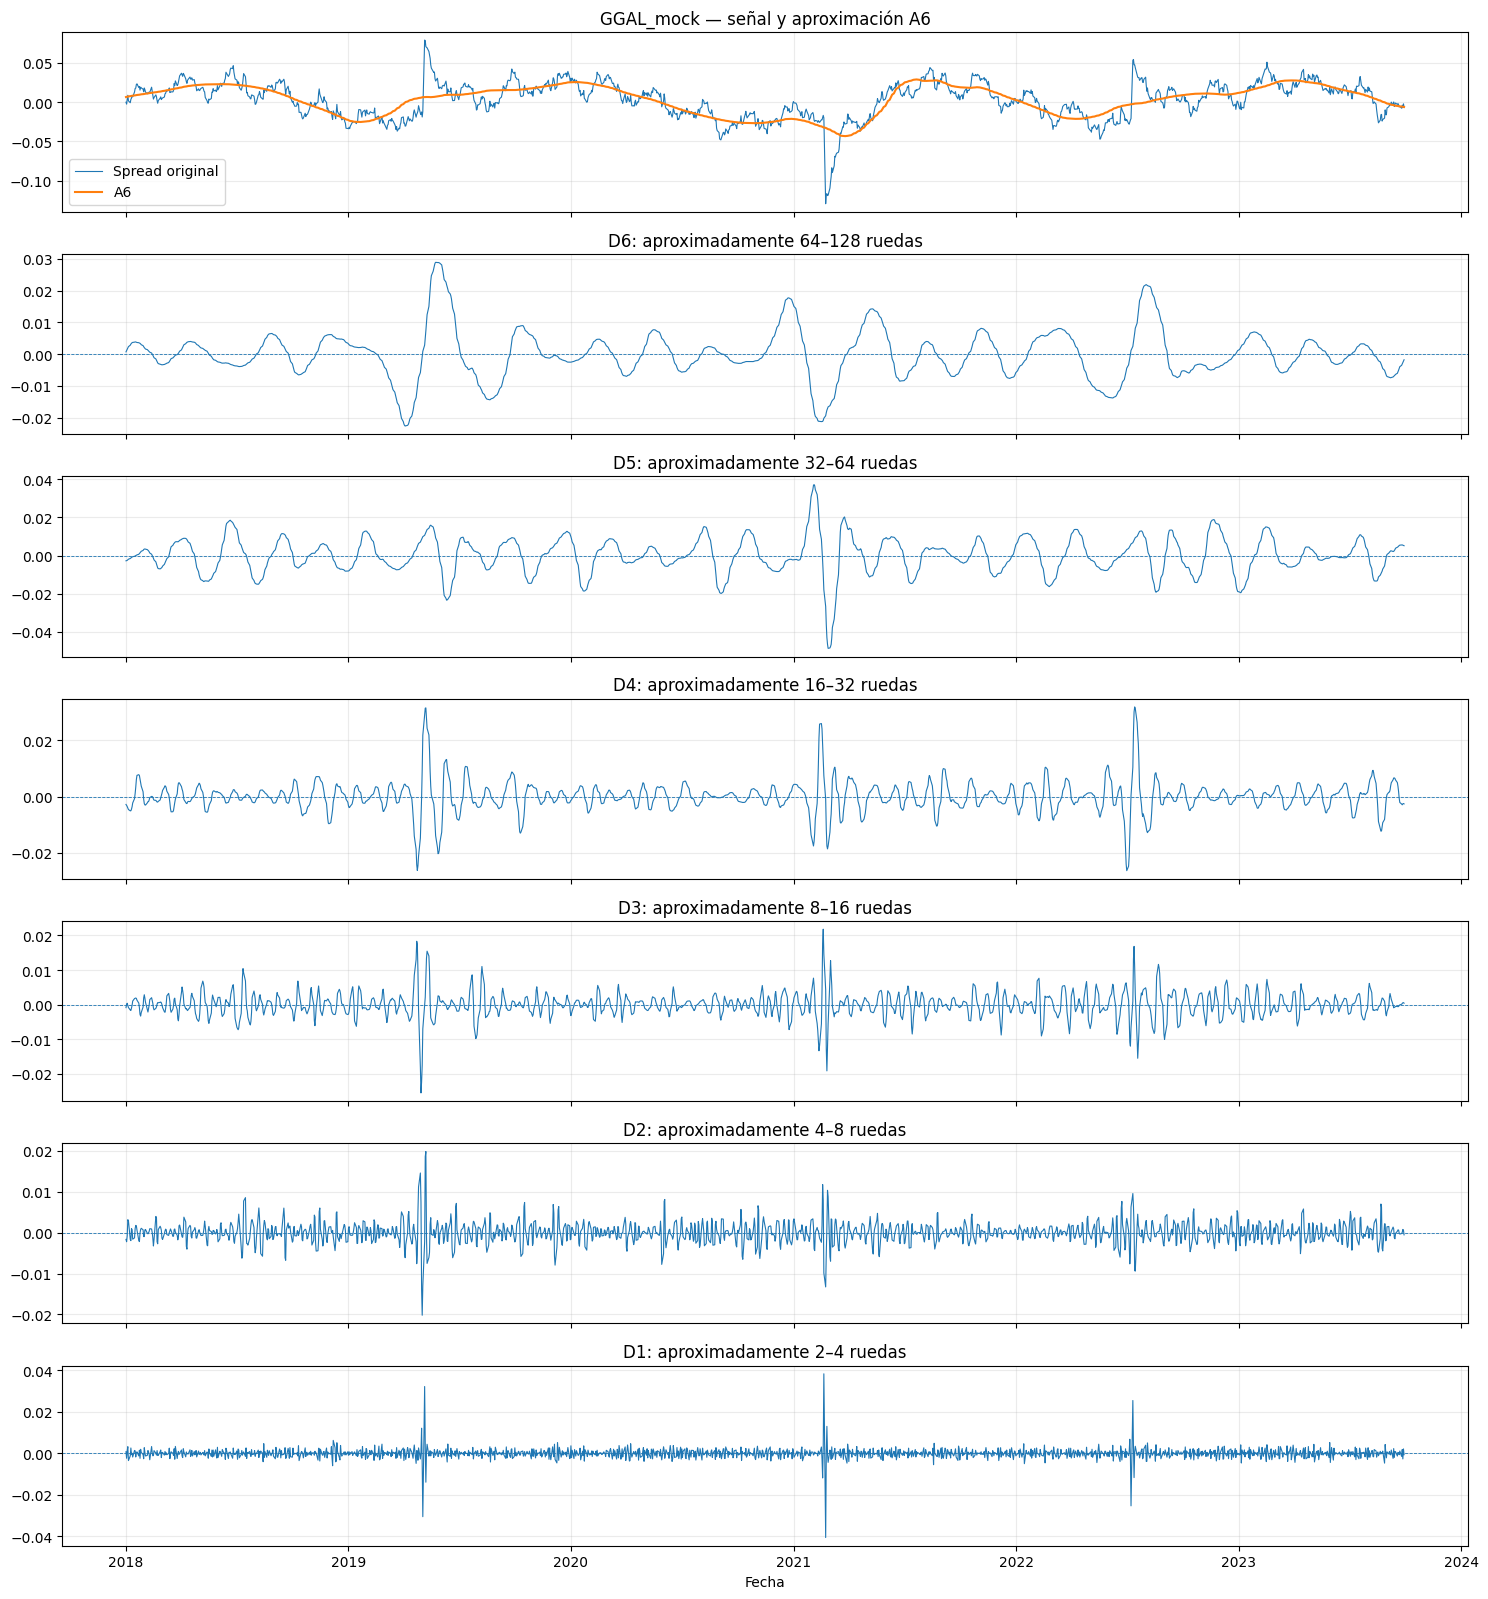

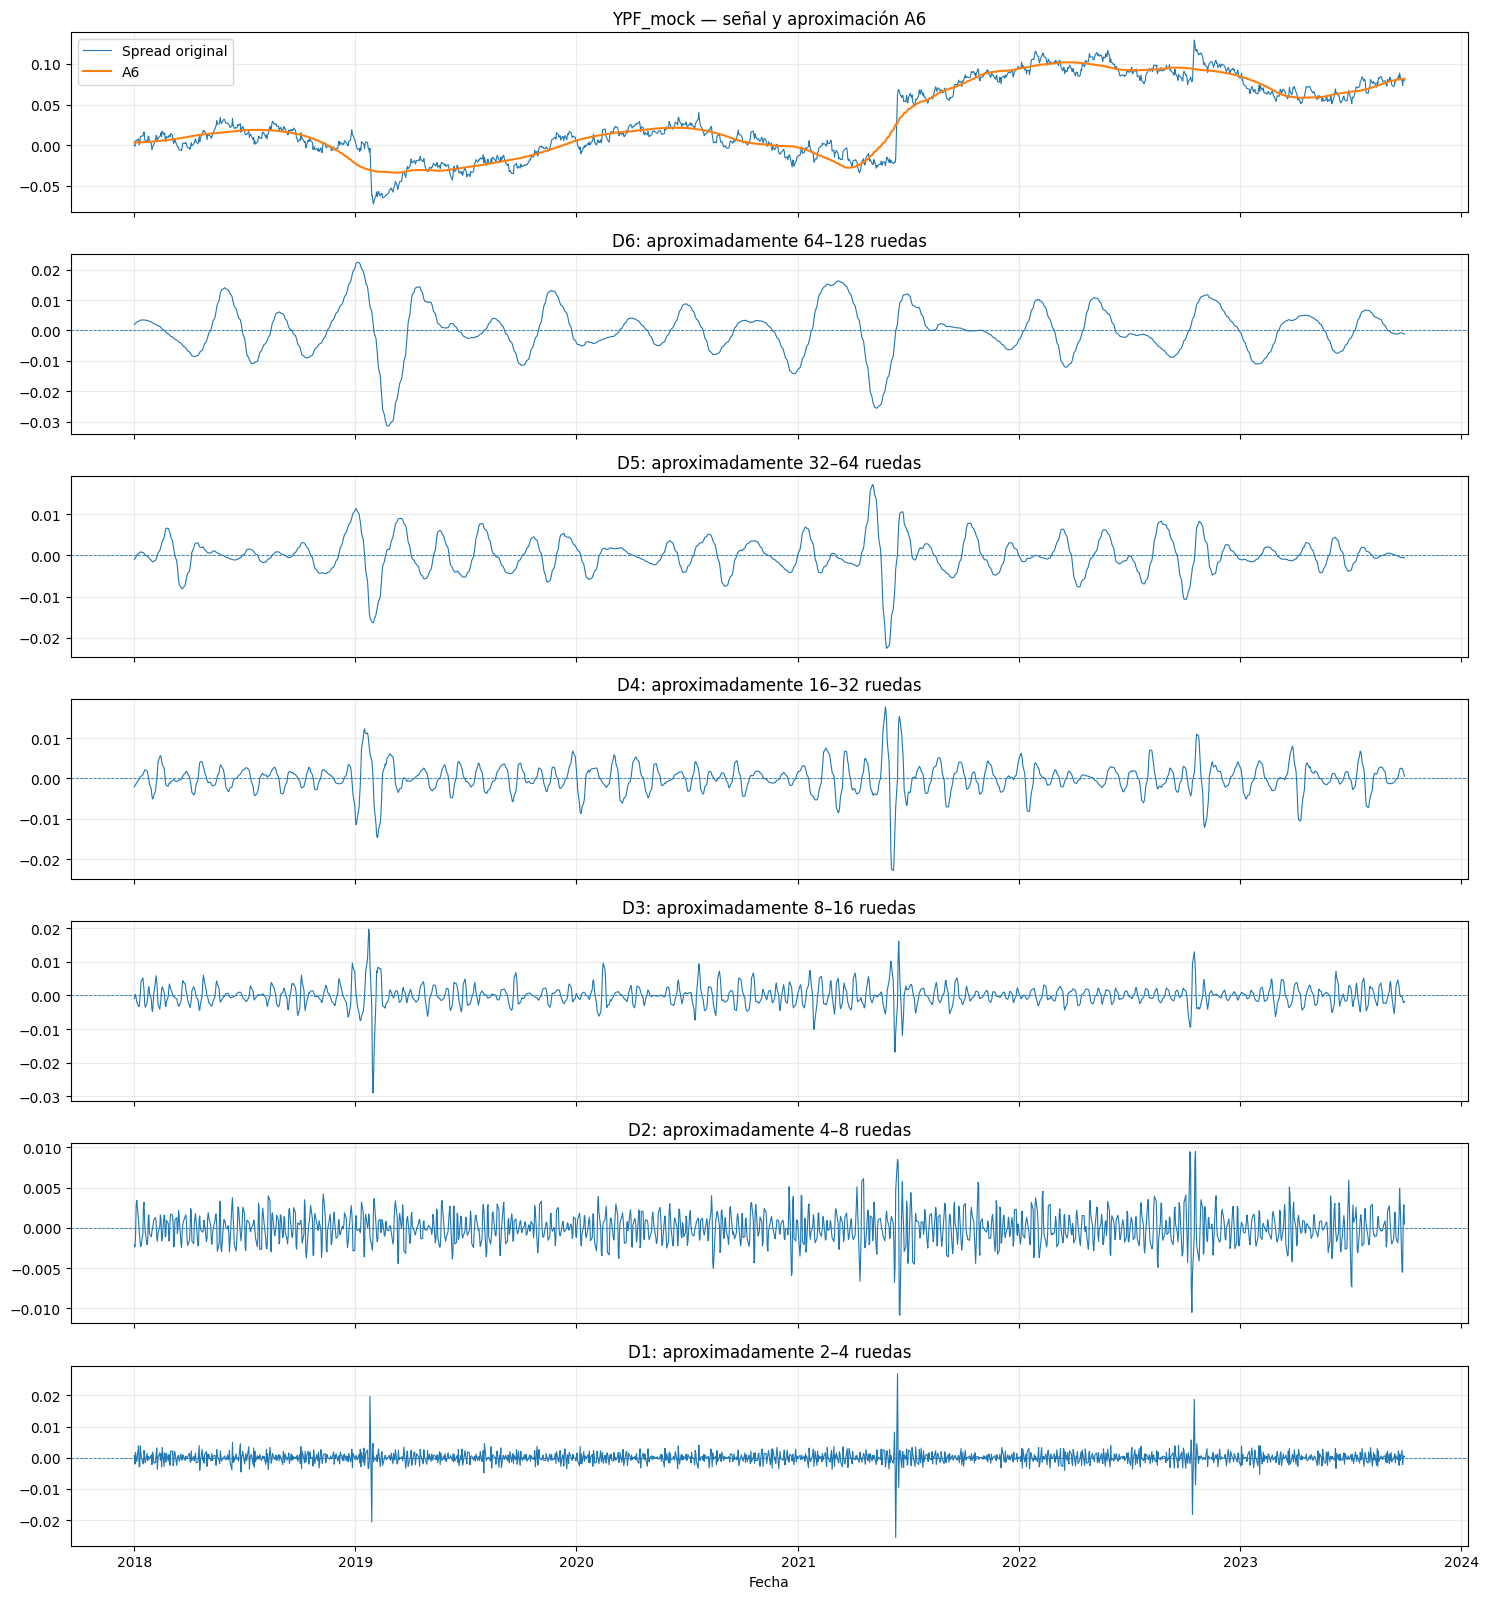

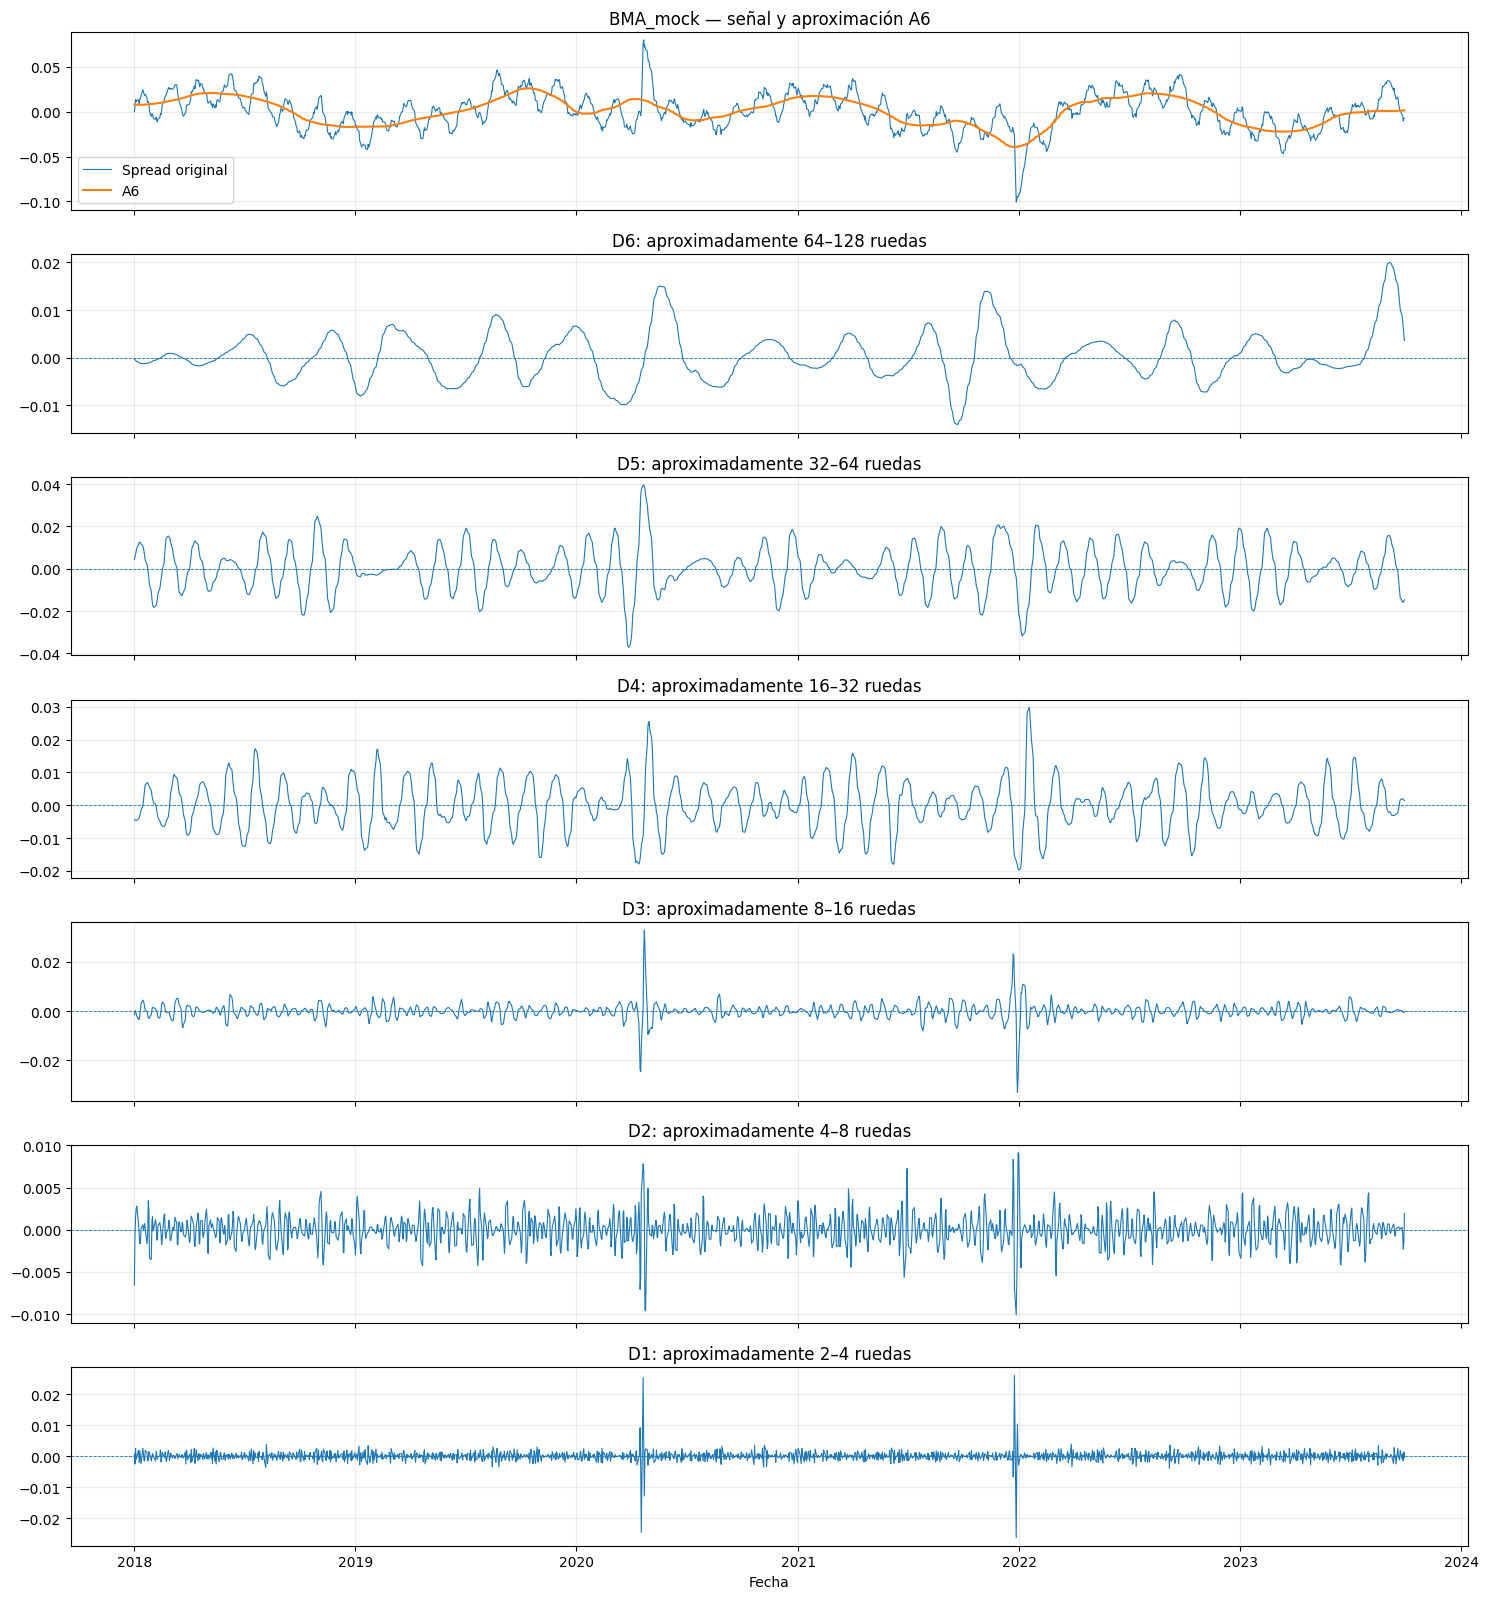

In [31]:
for ticker, reconstruccion in (
    reconstrucciones_mallat.items()
):
    graficar_componentes_mallat(
        reconstruccion=reconstruccion,
        ticker=ticker,
        nivel=NIVEL_MALLAT
    )

## Medir la "energia" de cada escala
#### Una energia alta indica que esa escala tiene una presencia importante en la señal

In [32]:
def calcular_energia_mallat(
    resultado: dict
) -> pd.DataFrame:
    """
    Calcula la energía total y promedio
    de los coeficientes de cada escala.
    """
    coeficientes = resultado["coeficientes"]
    nivel = resultado["nivel"]

    nombres = [
        f"A{nivel}",
        *[
            f"D{detalle}"
            for detalle in range(nivel, 0, -1)
        ]
    ]

    filas = []

    for nombre, coeficiente in zip(
        nombres,
        coeficientes
    ):
        energia_total = np.sum(
            np.abs(coeficiente) ** 2
        )

        filas.append(
            {
                "componente": nombre,
                "cantidad_coeficientes": len(coeficiente),
                "energia_total": energia_total,
                "energia_media_coeficiente": (
                    energia_total / len(coeficiente)
                )
            }
        )

    energia = pd.DataFrame(filas)

    total = energia["energia_total"].sum()

    energia["proporcion_energia"] = (
        energia["energia_total"] / total
    )

    return energia

In [33]:
energias_mallat = {
    ticker: calcular_energia_mallat(resultado)
    for ticker, resultado
    in resultados_mallat.items()
}

In [34]:
for ticker, energia in energias_mallat.items():
    print(f"\nEnergía por nivel — {ticker}")

    display(
        energia.style.format(
            {
                "energia_total": "{:.6f}",
                "energia_media_coeficiente": "{:.6f}",
                "proporcion_energia": "{:.2%}"
            }
        )
    )


Energía por nivel — GGAL_mock


,componente,cantidad_coeficientes,energia_total,energia_media_coeficiente,proporcion_energia
0,A6,30,0.509008,0.016967,61.18%
1,D6,30,0.093005,0.003100,11.18%
2,D5,53,0.140321,0.002648,16.87%
3,D4,100,0.047127,0.000471,5.66%
4,D3,193,0.019821,0.000103,2.38%
5,D2,380,0.010449,0.000027,1.26%
6,D1,753,0.012250,0.000016,1.47%



Energía por nivel — YPF_mock


,componente,cantidad_coeficientes,energia_total,energia_media_coeficiente,proporcion_energia
0,A6,30,4.874325,0.162478,96.52%
1,D6,30,0.099076,0.003303,1.96%
2,D5,53,0.028905,0.000545,0.57%
3,D4,100,0.019582,0.000196,0.39%
4,D3,193,0.015170,0.000079,0.30%
5,D2,380,0.006133,0.000016,0.12%
6,D1,753,0.007068,0.000009,0.14%



Energía por nivel — BMA_mock


,componente,cantidad_coeficientes,energia_total,energia_media_coeficiente,proporcion_energia
0,A6,30,0.349814,0.011660,50.34%
1,D6,30,0.068863,0.002295,9.91%
2,D5,53,0.171131,0.003229,24.63%
3,D4,100,0.078736,0.000787,11.33%
4,D3,193,0.016243,0.000084,2.34%
5,D2,380,0.004794,0.000013,0.69%
6,D1,753,0.005361,0.000007,0.77%


### Energía total versus energía media

##### No significan lo mismo.

### Energía total

##### Mide cuánto aporta globalmente el nivel.

##### Un nivel fino tiene más coeficientes y puede acumular bastante energía.

### Energía media por coeficiente

##### Mide qué tan intensos son, en promedio, los coeficientes de ese nivel.

##### Un nivel grueso puede tener pocos coeficientes, pero muy grandes.

##### Conviene mostrar ambas medidas.

### Gráfico de proporción de energía

In [35]:
def graficar_energia(
    energia: pd.DataFrame,
    ticker: str
) -> None:
    datos = energia.copy()

    plt.figure(figsize=(10, 5))

    plt.bar(
        datos["componente"],
        datos["proporcion_energia"]
    )

    plt.title(
        f"Distribución de energía por escala — {ticker}"
    )

    plt.xlabel("Componente")
    plt.ylabel("Proporción de energía")
    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

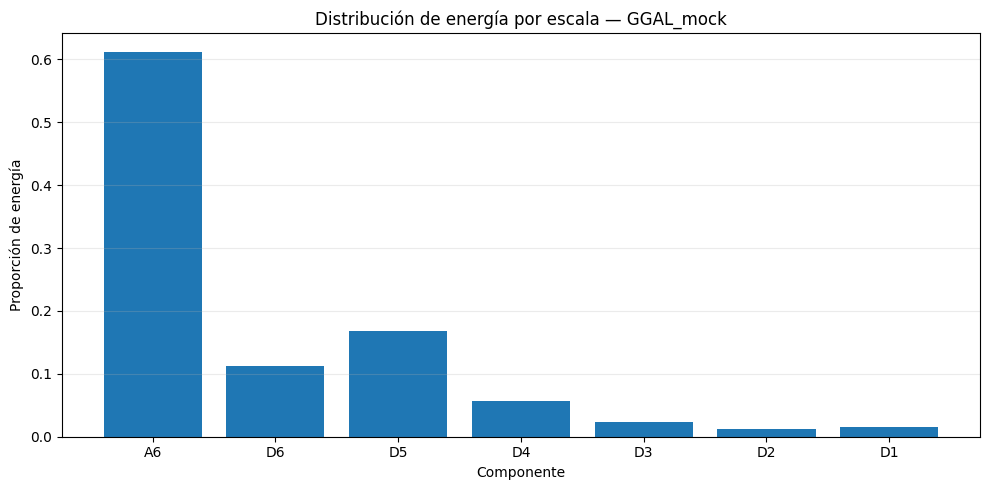

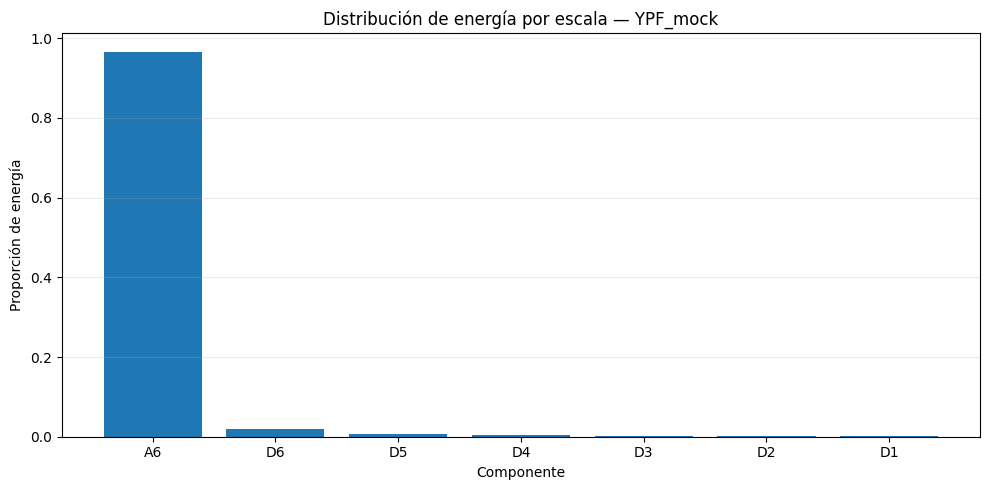

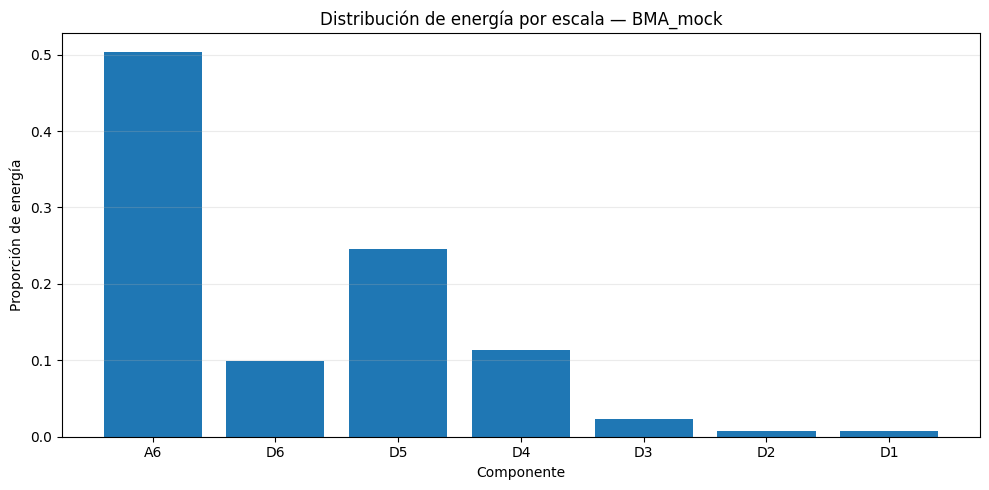

In [36]:
for ticker, energia in energias_mallat.items():
    graficar_energia(
        energia=energia,
        ticker=ticker
    )

#### Precaución
##### Como utilizamos extensión simétrica en los bordes, la energía de los coeficientes debe interpretarse como una medida descriptiva relativa.
##### No deberíamos afirmar que es una descomposición exacta de la varianza económica de la serie.

## Validar Mallat contra la verdad del mockdata (ELIMINAR DESPUES)

In [37]:
def nivel_detalle_para_periodo(
    periodo: float,
    nivel_maximo: int
) -> int | None:
    """
    Devuelve el nivel D_j cuya banda aproximada
    contiene al período indicado.
    """
    for nivel in range(1, nivel_maximo + 1):
        minimo = 2 ** nivel
        maximo = 2 ** (nivel + 1)

        if minimo <= periodo <= maximo:
            return nivel

    return None

In [38]:
periodos_intermedios_mock = {
    "GGAL_mock": 55,
    "YPF_mock": 80,
    "BMA_mock": 35
}

for ticker, periodo in (
    periodos_intermedios_mock.items()
):
    nivel = nivel_detalle_para_periodo(
        periodo=periodo,
        nivel_maximo=NIVEL_MALLAT
    )

    print(
        f"{ticker}: período {periodo} "
        f"→ aproximadamente D{nivel}"
    )

GGAL_mock: período 55 → aproximadamente D5
YPF_mock: período 80 → aproximadamente D6
BMA_mock: período 35 → aproximadamente D5


### Metricas de validacion

In [39]:
def correlacion_segura(
    x: pd.Series,
    y: pd.Series
) -> float:
    datos = pd.concat([x, y], axis=1).dropna()

    if len(datos) < 2:
        return np.nan

    return datos.iloc[:, 0].corr(
        datos.iloc[:, 1]
    )


def rmse(
    x: pd.Series,
    y: pd.Series
) -> float:
    datos = pd.concat([x, y], axis=1).dropna()

    return np.sqrt(
        np.mean(
            (
                datos.iloc[:, 0]
                - datos.iloc[:, 1]
            ) ** 2
        )
    )


def validar_con_componentes_mock(
    reconstrucciones: dict[str, pd.DataFrame],
    componentes_mock: dict[str, pd.DataFrame],
    periodos_intermedios: dict[str, float],
    nivel_maximo: int,
    margen_bordes: int = 128
) -> pd.DataFrame:
    """
    Compara las componentes recuperadas por Mallat
    contra las componentes verdaderas del mock.
    """
    filas = []

    for ticker, reconstruccion in (
        reconstrucciones.items()
    ):
        verdad = componentes_mock[ticker]

        if len(reconstruccion) <= 2 * margen_bordes:
            raise ValueError(
                "El margen de bordes elimina "
                "demasiadas observaciones."
            )

        rec_central = reconstruccion.iloc[
            margen_bordes:-margen_bordes
        ]

        verdad_central = verdad.iloc[
            margen_bordes:-margen_bordes
        ]

        periodo = periodos_intermedios[ticker]

        nivel_detalle = nivel_detalle_para_periodo(
            periodo=periodo,
            nivel_maximo=nivel_maximo
        )

        aproximacion = rec_central[
            f"A{nivel_maximo}"
        ]

        detalle_estimado = rec_central[
            f"D{nivel_detalle}"
        ]

        lenta_real = verdad_central["lenta"]
        media_real = verdad_central["media"]

        filas.append(
            {
                "ticker": ticker,
                "detalle_esperado": f"D{nivel_detalle}",
                "correlacion_A_lenta": correlacion_segura(
                    aproximacion,
                    lenta_real
                ),
                "rmse_A_lenta": rmse(
                    aproximacion,
                    lenta_real
                ),
                "correlacion_D_media": correlacion_segura(
                    detalle_estimado,
                    media_real
                ),
                "rmse_D_media": rmse(
                    detalle_estimado,
                    media_real
                )
            }
        )

    return pd.DataFrame(filas).set_index("ticker")

In [40]:
validacion_mock = validar_con_componentes_mock(
    reconstrucciones=reconstrucciones_mallat,
    componentes_mock=componentes_mock,
    periodos_intermedios=periodos_intermedios_mock,
    nivel_maximo=NIVEL_MALLAT,
    margen_bordes=128
)

display(
    validacion_mock.style.format(
        {
            "correlacion_A_lenta": "{:.3f}",
            "rmse_A_lenta": "{:.5f}",
            "correlacion_D_media": "{:.3f}",
            "rmse_D_media": "{:.5f}"
        }
    )
)

,detalle_esperado,correlacion_A_lenta,rmse_A_lenta,correlacion_D_media,rmse_D_media
ticker,,,,,
GGAL_mock,D5,0.740,0.01308,0.556,0.00878
YPF_mock,D6,0.981,0.00962,0.502,0.00748
BMA_mock,D5,0.799,0.00902,0.702,0.00831


### Comparacion visual

In [41]:
def comparar_mallat_con_mock(
    ticker: str,
    reconstruccion: pd.DataFrame,
    componentes_reales: pd.DataFrame,
    nivel_mallat: int,
    periodo_intermedio: float
) -> None:
    nivel_detalle = nivel_detalle_para_periodo(
        periodo=periodo_intermedio,
        nivel_maximo=nivel_mallat
    )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(15, 8),
        sharex=True
    )

    axes[0].plot(
        componentes_reales.index,
        componentes_reales["lenta"],
        label="Componente lenta verdadera",
        linewidth=1.5
    )

    axes[0].plot(
        reconstruccion.index,
        reconstruccion[f"A{nivel_mallat}"],
        label=f"A{nivel_mallat} estimada",
        linewidth=1
    )

    axes[0].set_title(
        f"{ticker} — componente lenta"
    )

    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        componentes_reales.index,
        componentes_reales["media"],
        label="Componente intermedia verdadera",
        linewidth=1.5
    )

    axes[1].plot(
        reconstruccion.index,
        reconstruccion[f"D{nivel_detalle}"],
        label=f"D{nivel_detalle} estimado",
        linewidth=1
    )

    axes[1].set_title(
        f"{ticker} — período simulado "
        f"de {periodo_intermedio} ruedas"
    )

    axes[1].legend()
    axes[1].grid(alpha=0.25)
    axes[1].set_xlabel("Fecha")

    plt.tight_layout()
    plt.show()

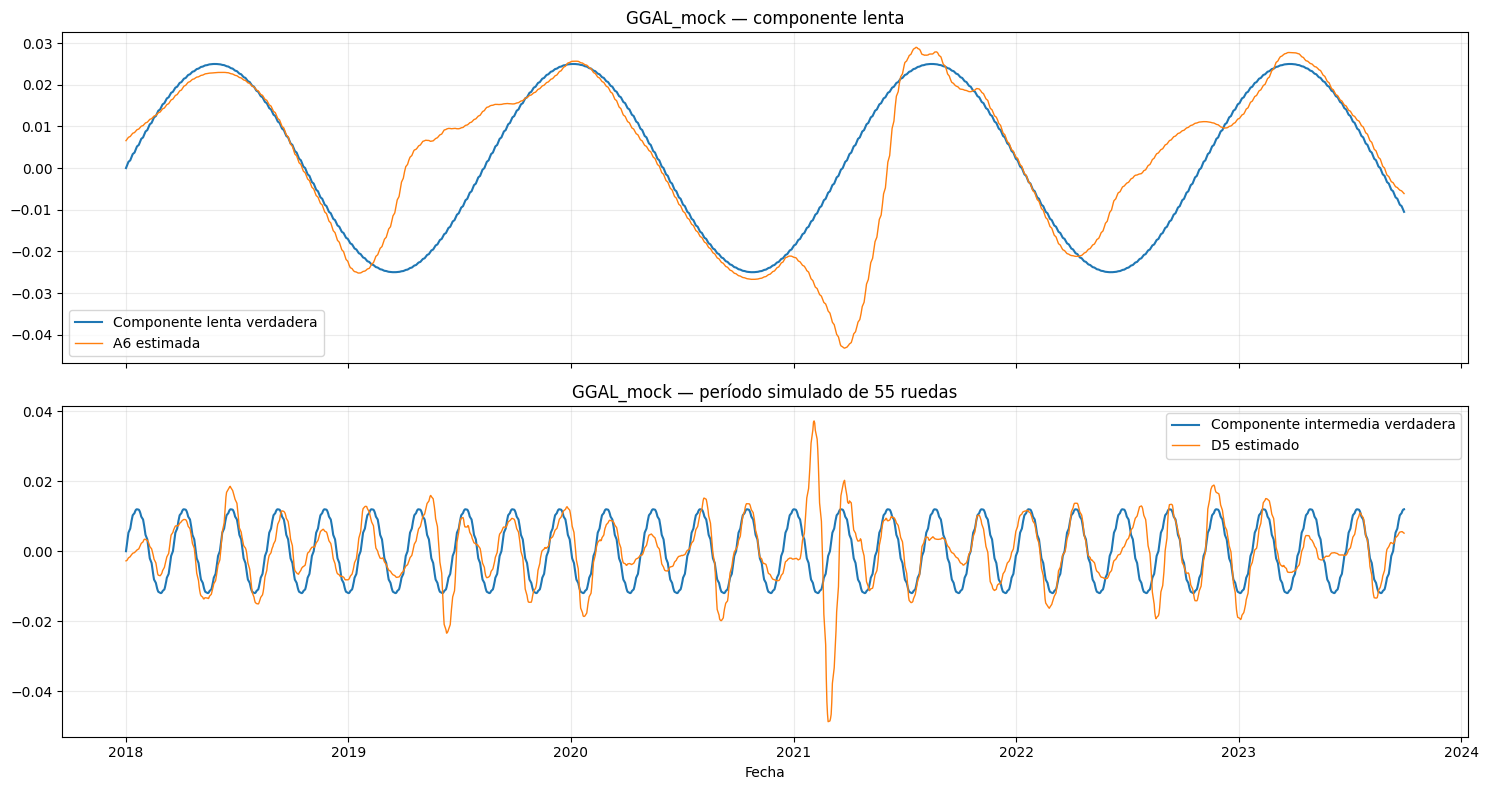

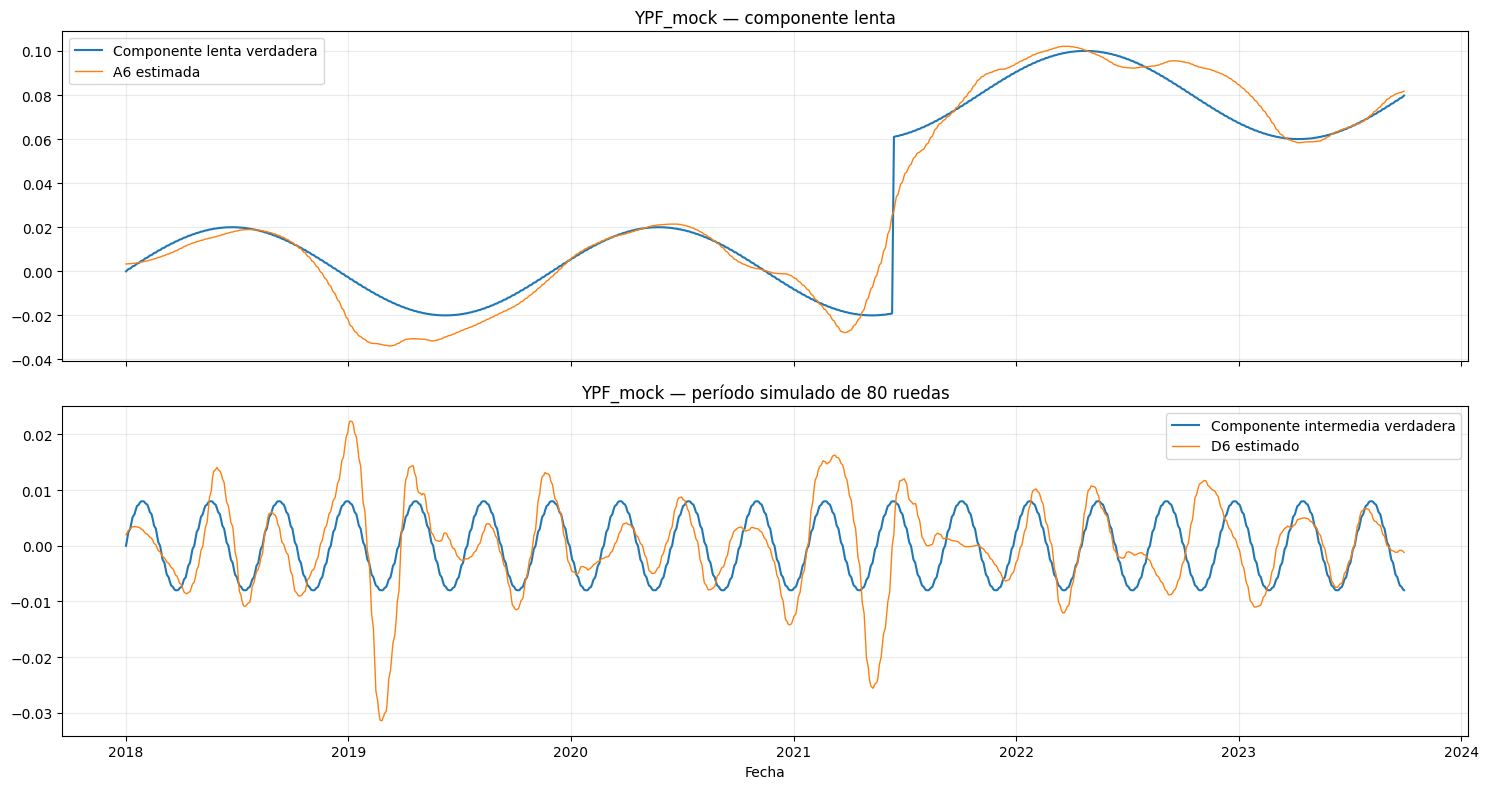

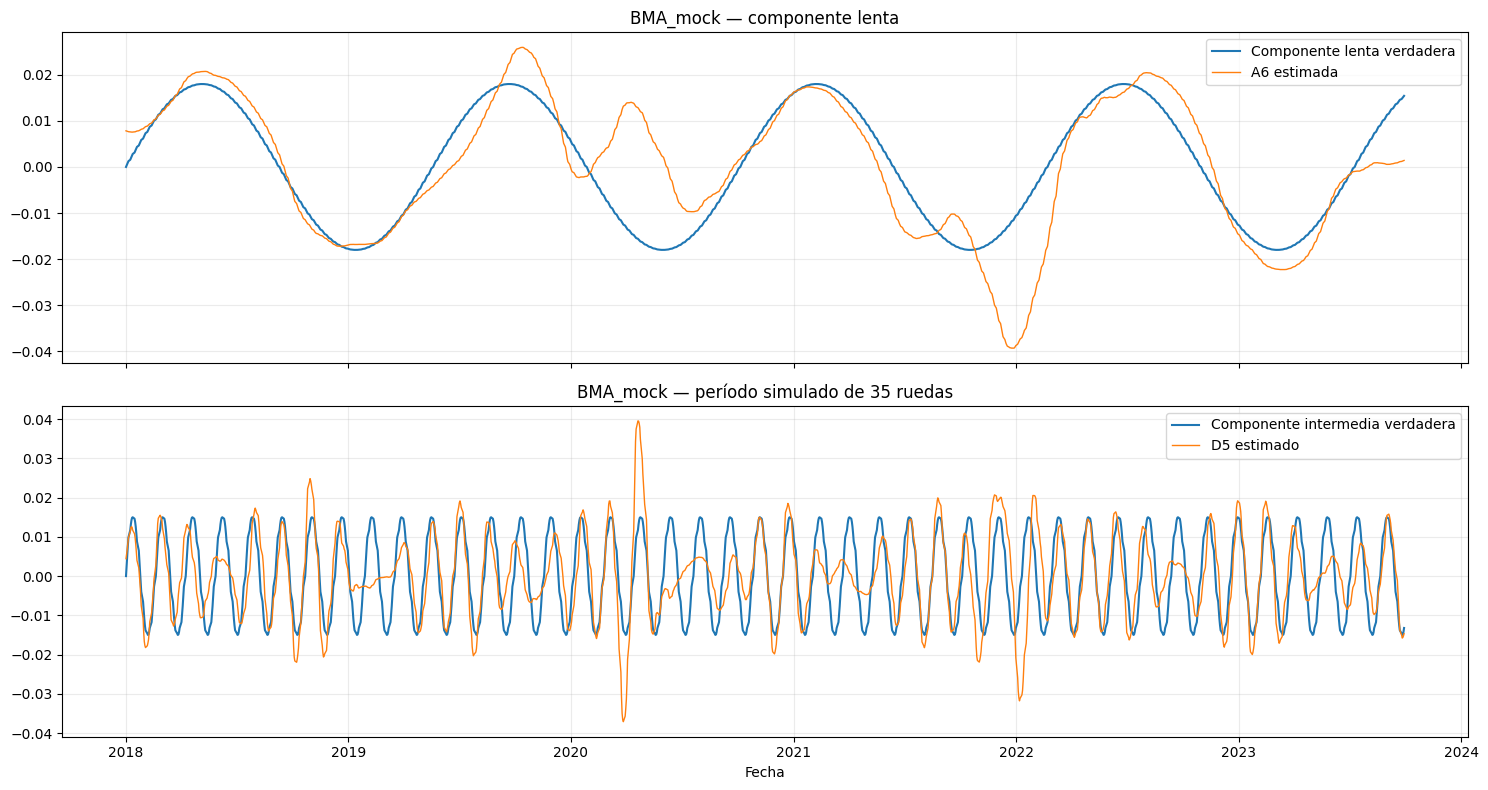

In [42]:
for ticker in spreads_df.columns:
    comparar_mallat_con_mock(
        ticker=ticker,
        reconstruccion=(
            reconstrucciones_mallat[ticker]
        ),
        componentes_reales=(
            componentes_mock[ticker]
        ),
        nivel_mallat=NIVEL_MALLAT,
        periodo_intermedio=(
            periodos_intermedios_mock[ticker]
        )
    )

La descomposición de Mallat permitió representar cada spread como la suma de una aproximación lenta y detalles asociados a diferentes escalas temporales. En los datos simulados, las oscilaciones de período conocido se concentraron principalmente en los niveles esperados, mientras que los shocks transitorios distribuyeron energía entre varias escalas. La aproximación capturó las tendencias lentas y el cambio estructural incluido en una de las señales. A diferencia de la FFT global, las componentes wavelet conservaron la localización temporal de los movimientos.

# Mallat Rolling
## Recontruccion en tiempo real para cada fecha, mallat solo va a ver observaciones disponibles hasta ese dia.

### Hasta ahora aplicamos Mallat sobre la serie completa, esto nos sirve para describir historicamente la señal pero tiene el problema de Data leaking.
#### Recalculamos mallat para cada fecha y conservamos solamente el ultimo valor recontruido.
#### Tenemos dos posivilidades, ventana expansiva (para fecha t usamos todos los datos desde el principio, aprovechamos todos los datos pero es computacionalmente costosa. Tambien una relacion de 2012 puede no ser representativa en 2024 y la interpretacion de la señal cambia con el tamaño de la muestra) o ventana fija (en la fecha t usamos solo las ultimas W observaciones, mantiene la escala temporal constante, se adapta a cambios recientes, es mas comparable entre fechas y cuesta menos computacionalmente. Vamos a usar esto con una ventana fija de 512 ruedas).
#### Usamos 512 observaciones para llegar al nivel 6 de mallat,comprobamos de la siguiente manera:


In [43]:
wavelet_obj = pywt.Wavelet(WAVELET)

for ventana in [128, 256, 512, 1024]:
    nivel_maximo = pywt.dwt_max_level(
        data_len=ventana,
        filter_len=wavelet_obj.dec_len
    )

    print(
        f"Ventana {ventana}: "
        f"nivel máximo recomendado = {nivel_maximo}"
    )

Ventana 128: nivel máximo recomendado = 4
Ventana 256: nivel máximo recomendado = 5
Ventana 512: nivel máximo recomendado = 6
Ventana 1024: nivel máximo recomendado = 7


### Configuracion de rolling (probar con borde smooth y constant tambien)

In [90]:
VENTANA_ROLLING = 512
NIVEL_ROLLING = 6
WAVELET_ROLLING = "db4"
MODO_BORDE_ROLLING = "symmetric"

#### Valido que la config sea posible

In [91]:
wavelet_obj = pywt.Wavelet(WAVELET_ROLLING)

nivel_maximo_ventana = pywt.dwt_max_level(
    data_len=VENTANA_ROLLING,
    filter_len=wavelet_obj.dec_len
)

if NIVEL_ROLLING > nivel_maximo_ventana:
    raise ValueError(
        f"Con una ventana de {VENTANA_ROLLING} "
        f"y wavelet {WAVELET_ROLLING}, "
        f"el máximo nivel recomendado es "
        f"{nivel_maximo_ventana}."
    )

print(
    f"Configuración válida: ventana={VENTANA_ROLLING}, "
    f"nivel={NIVEL_ROLLING}"
)

Configuración válida: ventana=512, nivel=6


## Recontruir solamente el ultimo punto
En cada ventana vamos a:

1. aplicar wavedec;
2. conservar la aproximación A
3. poner todos los detalles en cero;
4. reconstruir;
5. guardar únicamente el último valor.

In [92]:
def reconstruir_ultimo_punto_mallat(
    segmento: pd.Series,
    wavelet: str = "db4",
    nivel: int = 6,
    modo: str = "symmetric",
    conservar_aproximacion: bool = True,
    detalles_conservados: tuple[int, ...] = ()
) -> float:
    """
    Aplica Mallat sobre un segmento temporal y devuelve
    únicamente el último valor reconstruido.

    Parámetros
    ----------
    segmento:
        Ventana de datos disponible hasta una fecha t.

    conservar_aproximacion:
        Si es True, conserva A_n.

    detalles_conservados:
        Niveles D_j que también se desean conservar.
        Por ejemplo, (5, 6).

    Ejemplos
    --------
    Solo tendencia lenta:
        conservar_aproximacion=True
        detalles_conservados=()

    Tendencia más movimientos intermedios:
        conservar_aproximacion=True
        detalles_conservados=(5, 6)
    """
    if segmento.isna().any():
        raise ValueError(
            "El segmento contiene valores faltantes."
        )

    # Copia escribible y contigua para evitar:
    # "buffer source array is read-only".
    datos = np.ascontiguousarray(
        segmento.to_numpy(
            dtype=np.float64,
            copy=True
        )
    )

    wavelet_obj = pywt.Wavelet(wavelet)

    nivel_maximo = pywt.dwt_max_level(
        data_len=len(datos),
        filter_len=wavelet_obj.dec_len
    )

    if nivel > nivel_maximo:
        raise ValueError(
            f"El segmento de largo {len(datos)} "
            f"permite como máximo nivel {nivel_maximo}, "
            f"pero se solicitó nivel {nivel}."
        )

    coeficientes = pywt.wavedec(
        data=datos,
        wavelet=wavelet_obj,
        mode=modo,
        level=nivel
    )

    coeficientes_filtrados = [
        np.zeros_like(coeficiente)
        for coeficiente in coeficientes
    ]

    # wavedec devuelve:
    # [cA_n, cD_n, cD_{n-1}, ..., cD_1]
    if conservar_aproximacion:
        coeficientes_filtrados[0] = (
            coeficientes[0].copy()
        )

    for detalle in detalles_conservados:
        if detalle < 1 or detalle > nivel:
            raise ValueError(
                f"D{detalle} no existe. "
                f"Los niveles válidos son D1 a D{nivel}."
            )

        indice = nivel - detalle + 1

        coeficientes_filtrados[indice] = (
            coeficientes[indice].copy()
        )

    reconstruccion = pywt.waverec(
        coeficientes_filtrados,
        wavelet=wavelet_obj,
        mode=modo
    )

    # waverec puede devolver un punto adicional.
    reconstruccion = reconstruccion[:len(datos)]

    return float(reconstruccion[-1])

## Fucion rolling para una serie

In [93]:
def mallat_rolling_serie(
    serie: pd.Series,
    ventana: int = 512,
    wavelet: str = "db4",
    nivel: int = 6,
    modo: str = "symmetric",
    conservar_aproximacion: bool = True,
    detalles_conservados: tuple[int, ...] = ()
) -> pd.Series:
    """
    Calcula una reconstrucción rolling de Mallat.

    Para cada fecha usa solamente las últimas `ventana`
    observaciones disponibles hasta ese momento.

    Devuelve una serie con NaN antes de contar
    con suficientes observaciones.
    """
    if not isinstance(serie.index, pd.DatetimeIndex):
        raise TypeError(
            "La serie debe tener un DatetimeIndex."
        )

    if not serie.index.is_monotonic_increasing:
        raise ValueError(
            "Las fechas deben estar ordenadas."
        )

    if serie.index.has_duplicates:
        raise ValueError(
            "La serie contiene fechas duplicadas."
        )

    if serie.isna().any():
        raise ValueError(
            "La serie contiene valores faltantes."
        )

    wavelet_obj = pywt.Wavelet(wavelet)

    nivel_maximo = pywt.dwt_max_level(
        data_len=ventana,
        filter_len=wavelet_obj.dec_len
    )

    if nivel > nivel_maximo:
        raise ValueError(
            f"La ventana {ventana} permite como máximo "
            f"nivel {nivel_maximo}, no nivel {nivel}."
        )

    resultado = pd.Series(
        np.nan,
        index=serie.index,
        name=f"{serie.name}_mallat_rolling",
        dtype=float
    )

    # El primer resultado válido aparece cuando
    # tenemos una ventana completa.
    for posicion_final in range(
        ventana - 1,
        len(serie)
    ):
        posicion_inicial = (
            posicion_final - ventana + 1
        )

        segmento = serie.iloc[
            posicion_inicial:posicion_final + 1
        ]

        resultado.iloc[posicion_final] = (
            reconstruir_ultimo_punto_mallat(
                segmento=segmento,
                wavelet=wavelet,
                nivel=nivel,
                modo=modo,
                conservar_aproximacion=(
                    conservar_aproximacion
                ),
                detalles_conservados=(
                    detalles_conservados
                )
            )
        )

    return resultado

## Aplicamos a todos los spreads

In [94]:
def mallat_rolling_dataframe(
    spreads: pd.DataFrame,
    ventana: int = 512,
    wavelet: str = "db4",
    nivel: int = 6,
    modo: str = "symmetric",
    conservar_aproximacion: bool = True,
    detalles_conservados: tuple[int, ...] = ()
) -> pd.DataFrame:
    """
    Aplica Mallat rolling a cada columna de un DataFrame.
    """
    resultado = pd.DataFrame(
        index=spreads.index
    )

    for columna in spreads.columns:
        print(f"Procesando {columna}...")

        resultado[columna] = mallat_rolling_serie(
            serie=spreads[columna],
            ventana=ventana,
            wavelet=wavelet,
            nivel=nivel,
            modo=modo,
            conservar_aproximacion=(
                conservar_aproximacion
            ),
            detalles_conservados=(
                detalles_conservados
            )
        )

    return resultado

In [95]:
aproximaciones_rolling = mallat_rolling_dataframe(
    spreads=spreads_df,
    ventana=VENTANA_ROLLING,
    wavelet=WAVELET_ROLLING,
    nivel=NIVEL_ROLLING,
    modo=MODO_BORDE_ROLLING,
    conservar_aproximacion=True,
    detalles_conservados=()
)

Procesando GGAL_mock...
Procesando YPF_mock...
Procesando BMA_mock...


## Construimos en resudio en base a la componente lenta

In [96]:
residuos_rolling = (
    spreads_df - aproximaciones_rolling
)

residuos_rolling.columns = spreads_df.columns

#### aproximaciones_rolling representa la relacion lenta estimada en cada fecha y residuos_rolling representa las desviaciones rapidas o intermedias respecto a esa relacion

In [97]:
aproximaciones_rolling
residuos_rolling

,GGAL_mock,YPF_mock,BMA_mock
2018-01-01,NaN,NaN,NaN
2018-01-02,NaN,NaN,NaN
2018-01-03,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN
...,...,...,...
2023-09-25,-0.001854,-0.002711,-0.005103
2023-09-26,0.001118,-0.004728,-0.004265
2023-09-27,-0.001285,0.002064,-0.006795
2023-09-28,0.001997,0.002599,-0.003656


## Graficamos el resultado

In [98]:
def graficar_mallat_rolling(
    spread: pd.Series,
    aproximacion: pd.Series,
    residuo: pd.Series,
    ticker: str
) -> None:
    datos_validos = pd.concat(
        [
            spread.rename("spread"),
            aproximacion.rename("aproximacion"),
            residuo.rename("residuo")
        ],
        axis=1
    ).dropna()

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(15, 8),
        sharex=True
    )

    axes[0].plot(
        datos_validos.index,
        datos_validos["spread"],
        linewidth=0.8,
        label="Spread observado"
    )

    axes[0].plot(
        datos_validos.index,
        datos_validos["aproximacion"],
        linewidth=1.5,
        label=f"A{NIVEL_ROLLING} rolling"
    )

    axes[0].set_title(
        f"{ticker} — spread y aproximación Mallat rolling"
    )

    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        datos_validos.index,
        datos_validos["residuo"],
        linewidth=0.8
    )

    axes[1].axhline(
        y=0,
        linestyle="--",
        linewidth=0.7
    )

    axes[1].set_title(
        "Residuo: spread − aproximación rolling"
    )

    axes[1].set_ylabel("Desviación")
    axes[1].set_xlabel("Fecha")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

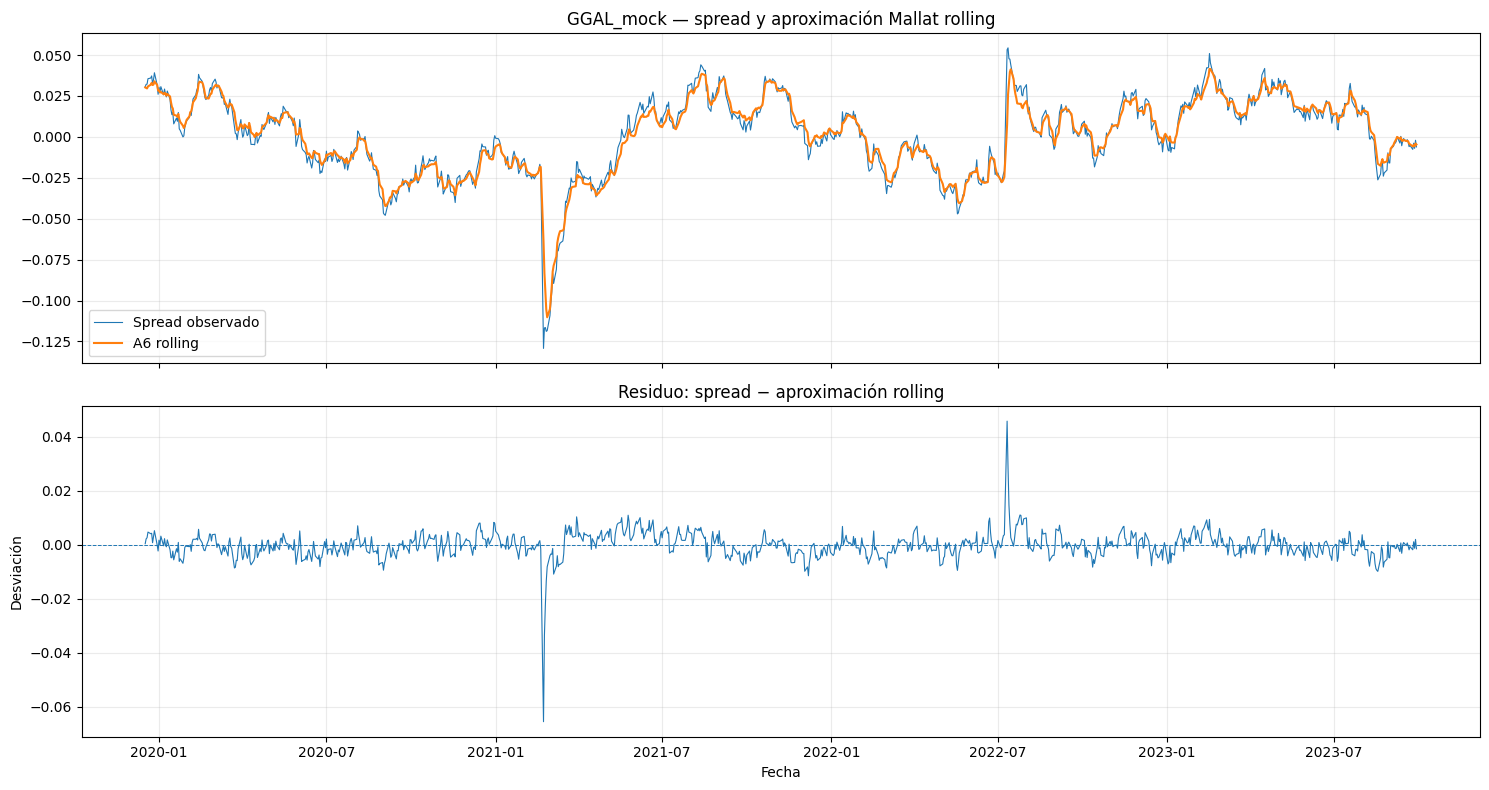

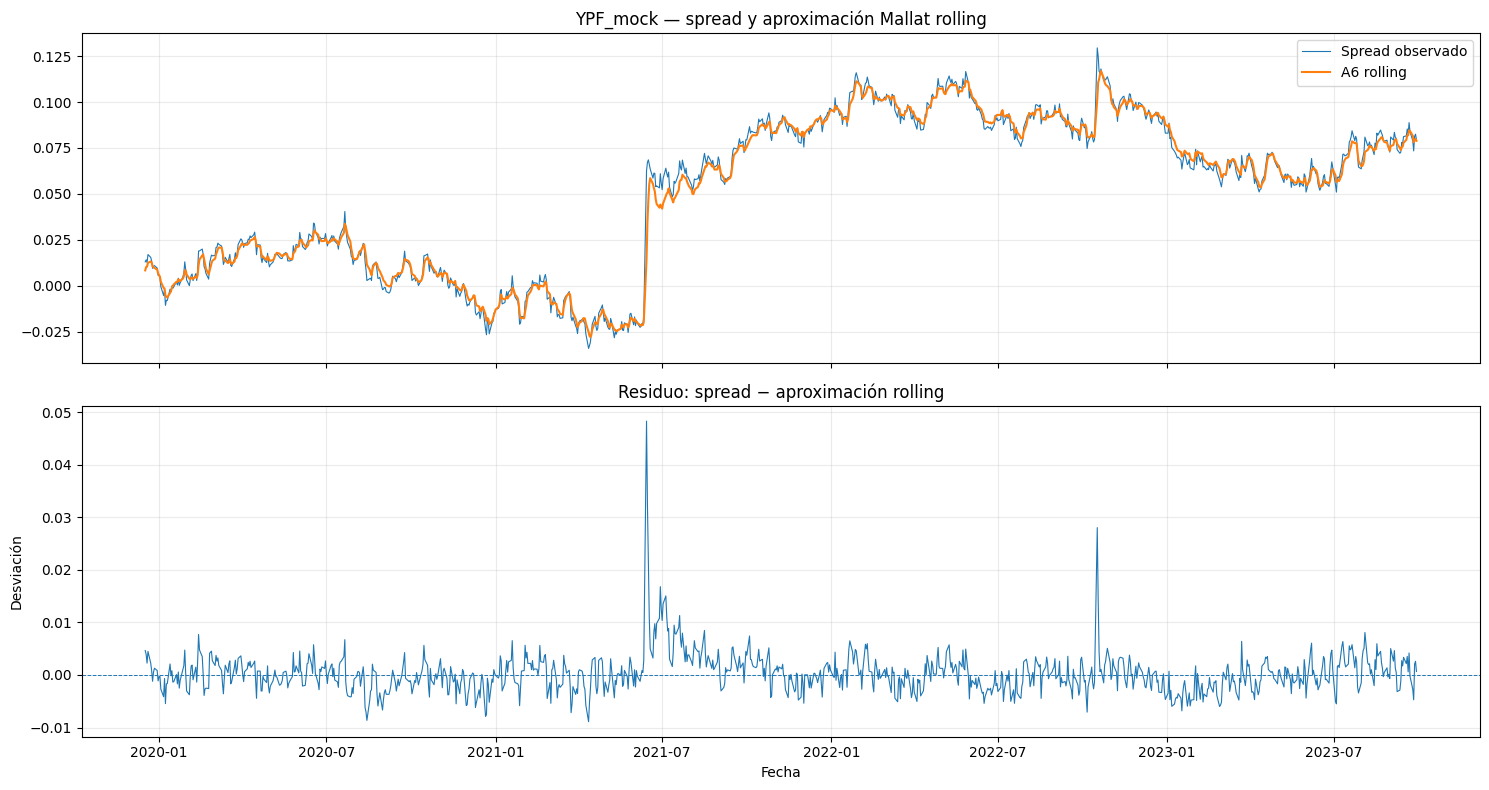

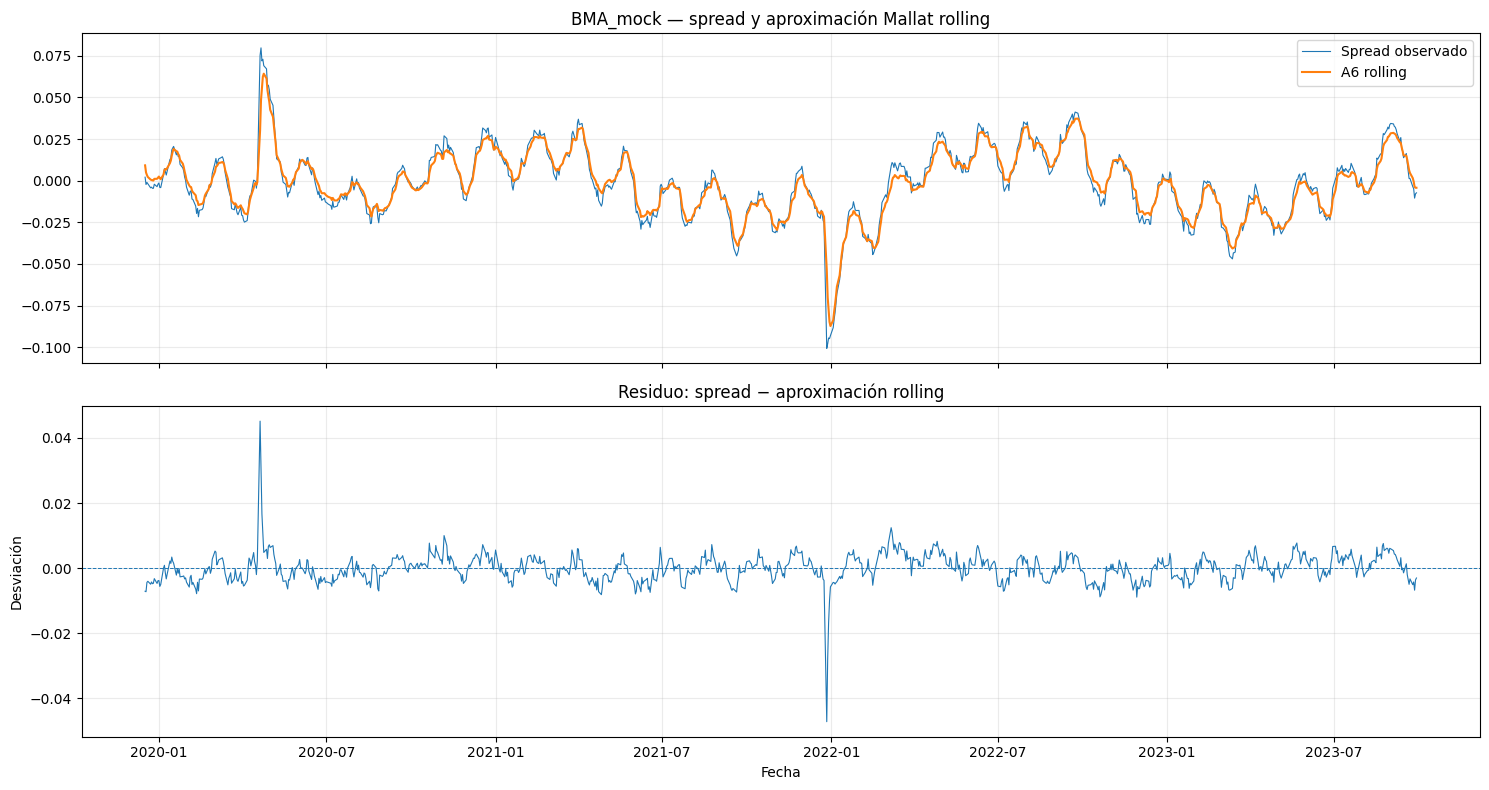

In [99]:
for ticker in spreads_df.columns:
    graficar_mallat_rolling(
        spread=spreads_df[ticker],
        aproximacion=aproximaciones_rolling[ticker],
        residuo=residuos_rolling[ticker],
        ticker=ticker
    )

## Probamos de que no hay data leakeage

In [100]:
def verificar_sin_lookahead(
    spreads: pd.DataFrame,
    aproximaciones_completas: pd.DataFrame,
    ventana: int,
    wavelet: str,
    nivel: int,
    modo: str,
    proporcion_corte: float = 0.75
) -> pd.DataFrame:
    """
    Recalcula el método usando una versión truncada
    de los datos y verifica que el pasado no cambie.
    """
    posicion_corte = int(
        len(spreads) * proporcion_corte
    )

    spreads_truncados = spreads.iloc[
        :posicion_corte
    ].copy()

    aproximaciones_truncadas = (
        mallat_rolling_dataframe(
            spreads=spreads_truncados,
            ventana=ventana,
            wavelet=wavelet,
            nivel=nivel,
            modo=modo,
            conservar_aproximacion=True,
            detalles_conservados=()
        )
    )

    filas = []

    for ticker in spreads.columns:
        comparacion = pd.concat(
            [
                aproximaciones_completas[
                    ticker
                ].iloc[:posicion_corte].rename(
                    "completo"
                ),
                aproximaciones_truncadas[
                    ticker
                ].rename("truncado")
            ],
            axis=1
        ).dropna()

        diferencia = (
            comparacion["completo"]
            - comparacion["truncado"]
        ).abs()

        filas.append(
            {
                "ticker": ticker,
                "observaciones_comparadas": len(
                    diferencia
                ),
                "diferencia_maxima": (
                    diferencia.max()
                ),
                "diferencia_media": (
                    diferencia.mean()
                )
            }
        )

    return pd.DataFrame(filas).set_index(
        "ticker"
    )

In [101]:
prueba_lookahead = verificar_sin_lookahead(
    spreads=spreads_df,
    aproximaciones_completas=(
        aproximaciones_rolling
    ),
    ventana=VENTANA_ROLLING,
    wavelet=WAVELET_ROLLING,
    nivel=NIVEL_ROLLING,
    modo=MODO_BORDE_ROLLING,
    proporcion_corte=0.75
)

display(prueba_lookahead)

Procesando GGAL_mock...
Procesando YPF_mock...
Procesando BMA_mock...


,observaciones_comparadas,diferencia_maxima,diferencia_media
ticker,,,
GGAL_mock,614,0.0,0.0
YPF_mock,614,0.0,0.0
BMA_mock,614,0.0,0.0


#### La implementación no presenta look-ahead, aunque la estimación del extremo puede ser sensible al tratamiento de bordes.

## Comparamos mallat completo vs mallat rolling

In [102]:
def comparar_completo_y_rolling(
    ticker: str,
    reconstruccion_completa: pd.DataFrame,
    aproximacion_rolling: pd.Series,
    nivel: int
) -> None:
    comparacion = pd.concat(
        [
            reconstruccion_completa[
                f"A{nivel}"
            ].rename("completa"),
            aproximacion_rolling.rename("rolling")
        ],
        axis=1
    ).dropna()

    plt.figure(figsize=(15, 5))

    plt.plot(
        comparacion.index,
        comparacion["completa"],
        label="Aproximación sobre muestra completa",
        linewidth=1.2
    )

    plt.plot(
        comparacion.index,
        comparacion["rolling"],
        label="Aproximación rolling",
        linewidth=1
    )

    plt.title(
        f"{ticker} — Mallat completo vs. rolling"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Aproximación")
    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

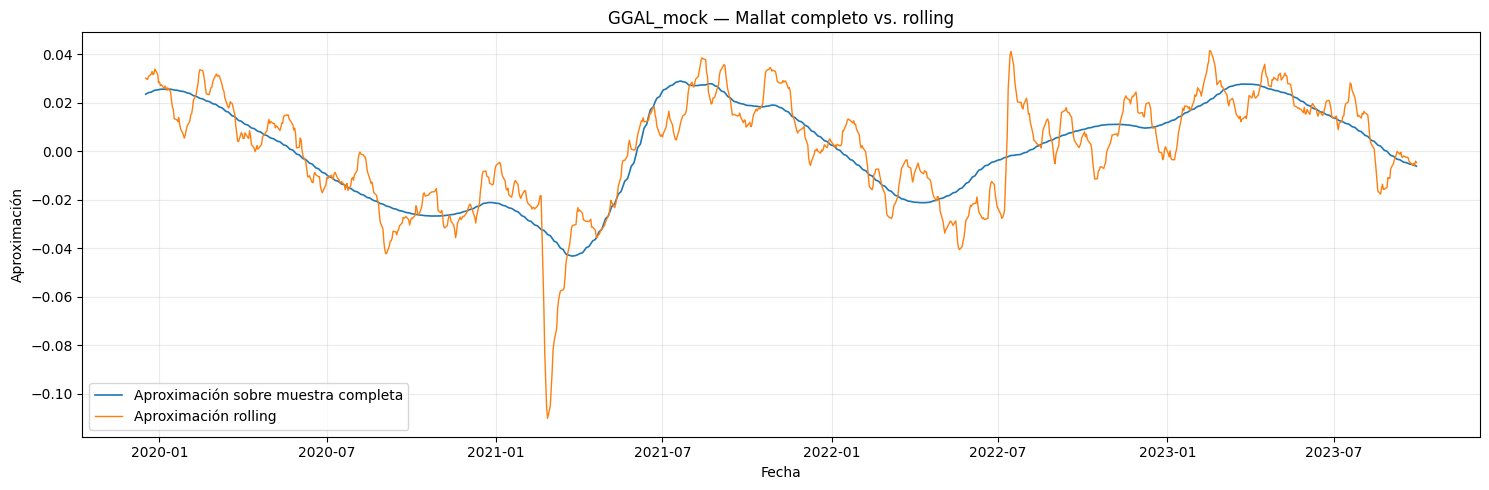

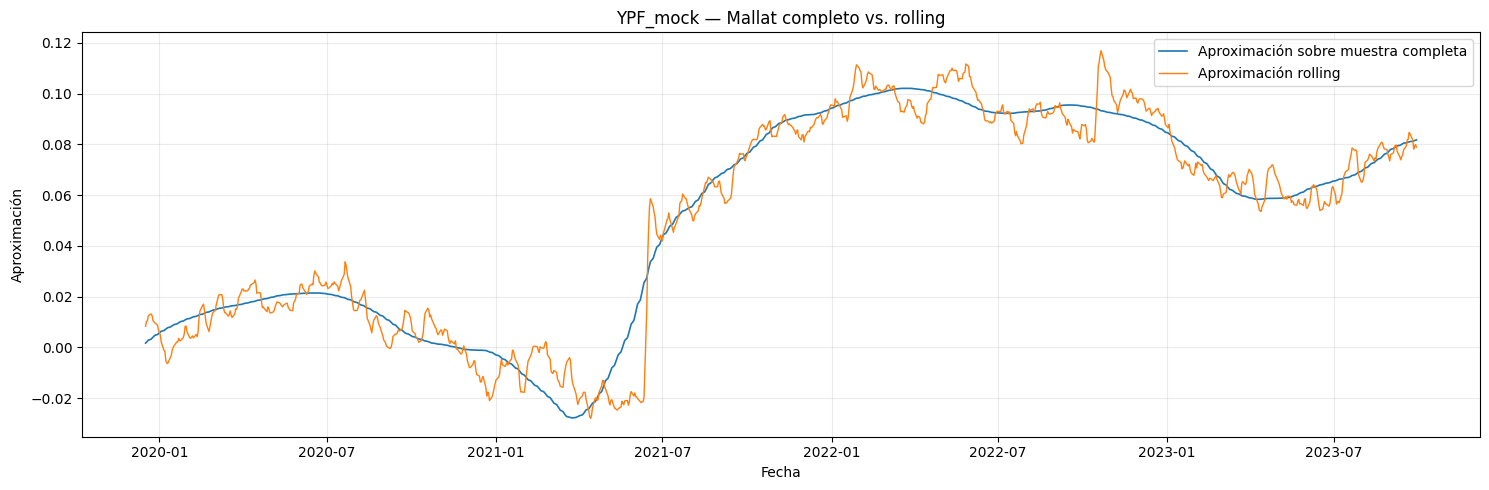

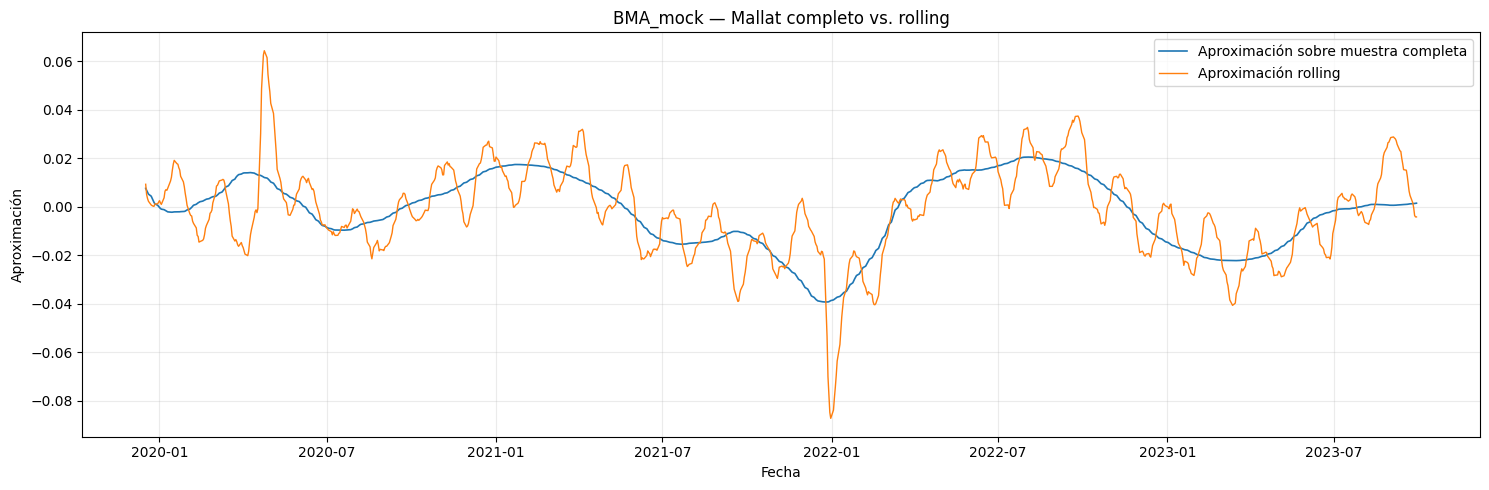

In [103]:
for ticker in spreads_df.columns:
    comparar_completo_y_rolling(
        ticker=ticker,
        reconstruccion_completa=(
            reconstrucciones_mallat[ticker]
        ),
        aproximacion_rolling=(
            aproximaciones_rolling[ticker]
        ),
        nivel=NIVEL_ROLLING
    )

### Medimos en cuanto difieren

In [104]:
def diagnosticar_revision_rolling(
    reconstrucciones_completas: dict,
    aproximaciones_rolling: pd.DataFrame,
    nivel: int
) -> pd.DataFrame:
    """
    Compara la estimación disponible en tiempo real
    con la reconstrucción obtenida usando toda la muestra.
    """
    filas = []

    for ticker in aproximaciones_rolling.columns:
        comparacion = pd.concat(
            [
                reconstrucciones_completas[ticker][
                    f"A{nivel}"
                ].rename("completa"),
                aproximaciones_rolling[
                    ticker
                ].rename("rolling")
            ],
            axis=1
        ).dropna()

        diferencia = (
            comparacion["completa"]
            - comparacion["rolling"]
        )

        filas.append(
            {
                "ticker": ticker,
                "correlacion": (
                    comparacion["completa"]
                    .corr(comparacion["rolling"])
                ),
                "rmse": np.sqrt(
                    np.mean(diferencia ** 2)
                ),
                "diferencia_absoluta_media": (
                    diferencia.abs().mean()
                ),
                "diferencia_absoluta_maxima": (
                    diferencia.abs().max()
                )
            }
        )

    return pd.DataFrame(filas).set_index(
        "ticker"
    )

In [105]:
diagnostico_revision = (
    diagnosticar_revision_rolling(
        reconstrucciones_completas=(
            reconstrucciones_mallat
        ),
        aproximaciones_rolling=(
            aproximaciones_rolling
        ),
        nivel=NIVEL_ROLLING
    )
)

display(diagnostico_revision)

,correlacion,rmse,diferencia_absoluta_media,diferencia_absoluta_maxima
ticker,,,,
GGAL_mock,0.855625,0.011650,0.008505,0.075900
YPF_mock,0.978492,0.008526,0.006221,0.045272
BMA_mock,0.750422,0.012531,0.009584,0.052301


## Validamos contra la verdad de los mock data

In [106]:
def validar_rolling_con_mock(
    aproximaciones_rolling: pd.DataFrame,
    componentes_mock: dict[str, pd.DataFrame]
) -> pd.DataFrame:
    filas = []

    for ticker in aproximaciones_rolling.columns:
        comparacion = pd.concat(
            [
                aproximaciones_rolling[
                    ticker
                ].rename("estimada"),
                componentes_mock[ticker][
                    "lenta"
                ].rename("verdadera")
            ],
            axis=1
        ).dropna()

        error = (
            comparacion["estimada"]
            - comparacion["verdadera"]
        )

        filas.append(
            {
                "ticker": ticker,
                "observaciones": len(comparacion),
                "correlacion": (
                    comparacion["estimada"]
                    .corr(comparacion["verdadera"])
                ),
                "rmse": np.sqrt(
                    np.mean(error ** 2)
                ),
                "mae": error.abs().mean()
            }
        )

    return pd.DataFrame(filas).set_index(
        "ticker"
    )

In [107]:
validacion_rolling_mock = validar_rolling_con_mock(
    aproximaciones_rolling=(
        aproximaciones_rolling
    ),
    componentes_mock=componentes_mock
)

display(
    validacion_rolling_mock.style.format(
        {
            "correlacion": "{:.3f}",
            "rmse": "{:.5f}",
            "mae": "{:.5f}"
        }
    )
)

,observaciones,correlacion,rmse,mae
ticker,,,,
GGAL_mock,989,0.666,0.01699,0.01099
YPF_mock,989,0.977,0.00911,0.00667
BMA_mock,989,0.579,0.01551,0.01088


## Usar solo A6 es lo mejor?
#### no, puede ser demasiado agresivo (eliminamos los movimientos menores a 128 ruedas)
#### podemos contruir una verison A6 + D6

In [108]:
aproximaciones_rolling_A6_D6 = (
    mallat_rolling_dataframe(
        spreads=spreads_df,
        ventana=VENTANA_ROLLING,
        wavelet=WAVELET_ROLLING,
        nivel=NIVEL_ROLLING,
        modo=MODO_BORDE_ROLLING,
        conservar_aproximacion=True,
        detalles_conservados=(6,)
    )
)

Procesando GGAL_mock...
Procesando YPF_mock...
Procesando BMA_mock...


## y + D5

In [109]:
aproximaciones_rolling_A6_D6_D5 = (
    mallat_rolling_dataframe(
        spreads=spreads_df,
        ventana=VENTANA_ROLLING,
        wavelet=WAVELET_ROLLING,
        nivel=NIVEL_ROLLING,
        modo=MODO_BORDE_ROLLING,
        conservar_aproximacion=True,
        detalles_conservados=(5, 6)
    )
)

Procesando GGAL_mock...
Procesando YPF_mock...
Procesando BMA_mock...


## Cuando se puede usar la señal
La aproximación en la fecha t utiliza el spread observado en t.

Por eso, en una aplicación financiera:

calculamos la señal al cierre de t;
tomamos la posición a partir de t+1.

La Persona 4 deberá usar algo semejante a:

posicion_aplicada = señal.shift(1)

Sin ese desplazamiento, se estaría utilizando la señal del cierre para capturar el retorno que ya ocurrió durante el mismo día.

#### Para evitar el uso de información futura, recalculamos la descomposición de Mallat mediante una ventana móvil. En cada fecha utilizamos únicamente las últimas 512 observaciones disponibles y conservamos el último valor de la reconstrucción. La aproximación obtenida representa la relación lenta estimada en tiempo real, mientras que la diferencia entre el spread observado y esa aproximación representa una desviación de menor escala. La prueba con una muestra truncada confirma que agregar observaciones futuras no modifica las estimaciones rolling ya calculadas. Sin embargo, los valores obtenidos en el extremo siguen siendo sensibles al método de extensión utilizado por la transformada.

#### La configuración db4, nivel 6 y ventana de 512 observaciones se utiliza como configuración inicial. La elección definitiva deberá realizarse mediante validación temporal sobre los spreads reales, comparando diferentes niveles, ventanas y modos de extensión.

# Creo una tabla de resumen

In [110]:
def resumir_resultados_mallat(
    spreads: pd.DataFrame,
    aproximaciones: pd.DataFrame,
    residuos: pd.DataFrame
) -> pd.DataFrame:
    filas = []

    for ticker in spreads.columns:
        datos = pd.concat(
            [
                spreads[ticker].rename("spread"),
                aproximaciones[ticker].rename("aproximacion"),
                residuos[ticker].rename("residuo")
            ],
            axis=1
        ).dropna()

        varianza_spread = datos["spread"].var()
        varianza_residuo = datos["residuo"].var()

        filas.append(
            {
                "ticker": ticker,
                "observaciones_totales": spreads[ticker].notna().sum(),
                "observaciones_rolling": len(datos),
                "media_spread": datos["spread"].mean(),
                "desvio_spread": datos["spread"].std(),
                "desvio_aproximacion": datos["aproximacion"].std(),
                "desvio_residuo": datos["residuo"].std(),
                "correlacion_spread_aproximacion": (
                    datos["spread"].corr(
                        datos["aproximacion"]
                    )
                ),
                "proporcion_varianza_residual": (
                    varianza_residuo / varianza_spread
                    if varianza_spread > 0
                    else np.nan
                )
            }
        )

    return pd.DataFrame(filas).set_index("ticker")

In [111]:
resumen_mallat_rolling = resumir_resultados_mallat(
    spreads=spreads_df,
    aproximaciones=aproximaciones_rolling,
    residuos=residuos_rolling
)

display(
    resumen_mallat_rolling.style.format(
        {
            "media_spread": "{:.5f}",
            "desvio_spread": "{:.5f}",
            "desvio_aproximacion": "{:.5f}",
            "desvio_residuo": "{:.5f}",
            "correlacion_spread_aproximacion": "{:.3f}",
            "proporcion_varianza_residual": "{:.2%}"
        }
    )
)

,observaciones_totales,observaciones_rolling,media_spread,desvio_spread,desvio_aproximacion,desvio_residuo,correlacion_spread_aproximacion,proporcion_varianza_residual
ticker,,,,,,,,
GGAL_mock,1500,989,0.00067,0.02423,0.02252,0.00484,0.981,3.98%
YPF_mock,1500,989,0.05078,0.04178,0.04132,0.00384,0.996,0.84%
BMA_mock,1500,989,-0.00174,0.02109,0.01895,0.00439,0.982,4.33%


## Creo una funcion para ejecutar todo el pipeline

In [ ]:
def procesar_spreads_con_mallat(
    spreads: pd.DataFrame,
    wavelet: str = "db4",
    nivel_descriptivo: int = 6,
    nivel_rolling: int = 6,
    ventana_rolling: int = 512,
    modo: str = "symmetric"
) -> dict:
    """
    Ejecuta el módulo completo de procesamiento
    de señales sobre un DataFrame de spreads.
    """
    validar_spreads(spreads)

    # FFT global.
    resultados_fft = {
        columna: calcular_espectro_fft(
            spreads[columna]
        )
        for columna in spreads.columns
    }

    # Mallat descriptivo sobre la muestra completa.
    resultados_mallat = descomponer_mallat(
        spreads=spreads,
        wavelet=wavelet,
        nivel=nivel_descriptivo,
        modo=modo
    )

    reconstrucciones = {
        ticker: reconstruir_todas_las_componentes(
            resultado
        )
        for ticker, resultado
        in resultados_mallat.items()
    }

    energias = {
        ticker: calcular_energia_mallat(
            resultado
        )
        for ticker, resultado
        in resultados_mallat.items()
    }

    # Mallat rolling.
    aproximaciones_rolling = (
        mallat_rolling_dataframe(
            spreads=spreads,
            ventana=ventana_rolling,
            wavelet=wavelet,
            nivel=nivel_rolling,
            modo=modo,
            conservar_aproximacion=True,
            detalles_conservados=()
        )
    )

    residuos_rolling = (
        spreads - aproximaciones_rolling
    )

    resumen = resumir_resultados_mallat(
        spreads=spreads,
        aproximaciones=aproximaciones_rolling,
        residuos=residuos_rolling
    )

    configuracion = {
        "wavelet": wavelet,
        "nivel_descriptivo": nivel_descriptivo,
        "nivel_rolling": nivel_rolling,
        "ventana_rolling": ventana_rolling,
        "modo_borde": modo
    }

    return {
        "configuracion": configuracion,
        "fft": resultados_fft,
        "mallat_completo": resultados_mallat,
        "reconstrucciones": reconstrucciones,
        "energias": energias,
        "aproximaciones_rolling": aproximaciones_rolling,
        "residuos_rolling": residuos_rolling,
        "resumen_rolling": resumen
    }

In [ ]:
resultados_persona_3 = procesar_spreads_con_mallat(
    spreads=spreads_df,
    wavelet="db4",
    nivel_descriptivo=6,
    nivel_rolling=6,
    ventana_rolling=512,
    modo="symmetric"
)